# Projeto Final de Machine Learning - Classificação de Câncer de Pele 

## Colaboradores

- Pedro Paulo Moreno Camargo

- Thomas Chabro

- Caio Aranha

## Configurações de Ambiente

O objetivo desta seção é preparar o ambiente com as configurações necessárias para executar o projeto.

---


### Dependências 

#### Python e configuração básica

In [1]:
import os
import shutil
import random
from collections import Counter
os.environ["KAGGLE_CONFIG_DIR"] = "."

#### Modelagem de Dados

In [2]:
import numpy as np
import pandas as pd
from imblearn.over_sampling import RandomOverSampler

#### Visualização de dados

In [3]:
from PIL import Image
import matplotlib.patches as patches
import seaborn as sns
import matplotlib.pyplot as plt

#### Machine Learning

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)
from tensorflow.keras import layers, regularizers
from sklearn.preprocessing import label_binarize
from tensorflow.keras.utils import to_categorical
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input, Concatenate
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import keras_cv

#### Kaggle

In [5]:
# Configuração da API do Kaggle
from kaggle.api.kaggle_api_extended import KaggleApi

---

### Variáveis Globais

#### Variáveis de diretório

In [6]:
DATA_DIR = "data"
DATASET_NAME = "kmader/skin-cancer-mnist-ham10000"
src_dirs = [os.path.join(DATA_DIR, "HAM10000_images_part_1"), os.path.join(DATA_DIR, "HAM10000_images_part_2")]
dst_dir = os.path.join(DATA_DIR, "HAM10000_images")
METADATA_PATH = os.path.join(DATA_DIR, "HAM10000_metadata.csv")
IMAGES_DIR = os.path.join(DATA_DIR, "HAM10000_images")

Definiu-se:

- `DATA_DIR`: diretório base onde todos os dados do projeto serão armazenados (`data`);
- `DATASET_NAME`: identificador do dataset no Kaggle (`kmader/skin-cancer-mnist-ham10000`);
- `src_dirs`: lista com os diretórios originais das imagens (`HAM10000_images_part_1` e `HAM10000_images_part_2`);
- `dst_dir`: diretório final onde todas as imagens serão consolidadas (`HAM10000_images`);
- `METADATA_PATH`: caminho completo para o arquivo `HAM10000_metadata.csv`;
- `IMAGES_DIR`: caminho para o diretório que contém todas as imagens utilizadas pelo modelo.

#### Variáveis de Classes

In [7]:
# Dicionário de classes
class_names = {
    'nv': 'Nevos melanocíticos',
    'mel': 'Melanoma',
    'bkl': 'Queratose benigna',
    'bcc': 'Carcinoma basocelular',
    'akiec': 'Queratose actínica',
    'vasc': 'Lesões vasculares',
    'df': 'Dermatofibroma'
}
num_classes = len(class_names)

Definiu-se: 
- `class_names`: dicionário que mapeia os códigos do diagnóstico (`dx`) para nomes descritivos em português.

#### Variáveis das Imagens

In [8]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 3

Definiu-se:

- `IMG_HEIGHT`: altura para a qual todas as imagens serão redimensionadas (128 pixels).
- `IMG_WIDTH`: largura usada no redimensionamento das imagens (128 pixels).
- `CHANNELS`: número de canais de cor; usamos 3 para imagens RGB.

#### Variáveis de ML

In [9]:
# Seed para reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
# Tamanho do batch para treinamento
BATCH_SIZE = 32
# Número de épocas para treinamento
EPOCHS = 30

# Proporções de validação e teste em relação ao total
VAL_SIZE = 0.15   # 15% para validação
TEST_SIZE = 0.15  # 15% para teste
AUTOTUNE = tf.data.AUTOTUNE

Definiu-se:


- `SEED`: semente global usada para sincronizar todos os geradores pseudoaleatórios.  
  Aplicada em:
  - `random.seed(SEED)`  
  - `np.random.seed(SEED)`  
  - `tf.random.set_seed(SEED)`  
  Isso reduz variação nos splits, inicializações de pesos e operações aleatórias.
- `BATCH_SIZE`: número de imagens processadas antes de cada atualização de gradiente  
  (define o tamanho do batch).
- `EPOCHS`: quantidade de ciclos completos de treinamento sobre o dataset.
- `VAL_SIZE`: porcentagem reservada para validação (15%).  
- `TEST_SIZE`: porcentagem reservada para teste final (15%).
- `AUTOTUNE`: Permite que o TensorFlow ajuste automaticamente o grau de paralelismo ao processar o dataset.

---

### Carregamento de Dados

#### Download via Kaggle

Baixe o seu token no site do kaggle e adicione o arquivo `kaggle.json` na raiz do projeto.

In [10]:
# Diretório para salvar os dados
os.makedirs(DATA_DIR, exist_ok=True)

# Autenticação na API do Kaggle
api = KaggleApi()
api.authenticate()

# Download do dataset
print("Baixando dataset...")
api.dataset_download_files(DATASET_NAME, path=DATA_DIR, unzip=True)
print("✅ Download e extração concluídos!")

Baixando dataset...
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
✅ Download e extração concluídos!


#### Organização das imagens em um diretório único

Após o download, as imagens do HAM10000 vêm separadas em duas pastas: `HAM10000_images_part_1` e `HAM10000_images_part_2`. Para simplificar o acesso, o conteúdo das pastas foi concatenado em um único diretório.

In [11]:
# Criar diretório final se não existir
os.makedirs(dst_dir, exist_ok=True)

for src in src_dirs:
    for filename in os.listdir(src):
        src_path = os.path.join(src, filename)
        dst_path = os.path.join(dst_dir, filename)

        # Move apenas arquivos
        if os.path.isfile(src_path):
            shutil.move(src_path, dst_path)

    # Após mover tudo, remover pasta antiga
    shutil.rmtree(src)

print(f"Imagens movidas para /{dst_dir} e diretórios antigos removidos!")

Imagens movidas para /data\HAM10000_images e diretórios antigos removidos!


---

## Análise Exploratória do Dataset

O objetivo desta seção é entender o conjunto de dados **HAM10000** e seus metadados (idade, sexo e localização anatômica) antes de treinar os modelos.  

---


### 1. Visão geral do dataset

O dataset **HAM10000** contém sete tipos de lesões cutâneas pigmentadas.
Cada amostra possui:

- uma imagem dermatoscópica;
- um registro de metadados (idade, sexo, localização anatômica etc.).

As classes presentes são:

- **Melanocytic nevi (`nv`)** – nevos melanocíticos benignos;
- **Melanoma (`mel`)** – melanoma maligno;
- **Benign keratosis (`bkl`)** – queratoses benignas;
- **Basal cell carcinoma (`bcc`)** – carcinoma basocelular;
- **Actinic keratoses (`akiec`)** – queratose actínica;
- **Dermatofibroma (`df`)** – dermatofibroma;
- **Vascular lesions (`vasc`)** – lesões vasculares.

---


### 2. Metadados

#### 2.1 Estrutura e qualidade dos dados

In [10]:
# Lê arquivo de METADATA
metadata_df = pd.read_csv(METADATA_PATH)
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [11]:
metadata_df[["dx", "sex", "localization", "dx_type"]].describe()

,dx,sex,localization,dx_type
count,10015,10015,10015,10015
unique,7,3,15,4
top,nv,male,back,histo
freq,6705,5406,2192,5340


In [12]:
metadata_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


O dataframe utilizado possui **10.015 linhas**, cada uma representando uma lesão, com colunas como:

- `image_id`: identificador único da imagem;
- `lesion_id`: identificador da lesão (podem existir múltiplas imagens da mesma lesão);
- `dx`: classe diagnosticada [7 tipos de classe diferentes] (`bkl`, `nv`, ...);
- `dx_type`: tipo de confirmação diagnóstica [4 tipos diferentes](`histopatologia`, `acompanhamento`, ...);
- `age`: idade do paciente;
- `sex`: sexo do paciente [3 classificações](`male`, `female` ou `unknown`);
- `localization`: localização anatômica da lesão [15 locais diferentes] (`face`, `peito`, ...).

Apenas o atributo **`age`** apresenta valores ausentes: 70 registros (~0,7% do total) não possuem idade informada.  

---

#### 2.2 Enriquecimento do dataframe

In [13]:
# Cria image_path a partir do image_id
metadata_df["image_path"] = metadata_df["image_id"].apply(
    lambda x: os.path.join(IMAGES_DIR, f"{x}.jpg")
)

# Mantém apenas registros com imagens existentes
metadata_df = metadata_df[metadata_df["image_path"].apply(os.path.exists)].reset_index(drop=True)

In [14]:
# Adicionar nome amigável e índice numérico
metadata_df['class_name'] = metadata_df['dx'].map(class_names)
metadata_df['class_idx'] = pd.Categorical(metadata_df['dx']).codes

Para facilitar o uso do dataset nas demais etapas do projeto, foram adicionadas ao dataframe novas colunas:

- **`image_path`** – caminho completo até o arquivo `.jpg` a partir de `image_id`, o que simplifica o carregamento das imagens;
- **`class_name`** – nome descritivo da classe, obtido mapeando o código `dx` para um rótulo legível (por exemplo, `nv` → *Nevos melanocíticos*);
- **`class_idx`** – rótulo numérico (0–6) associado a cada classe, usado como alvo nos modelos de classificação.

Além disso, o dataframe foi filtrado para manter apenas as linhas cujas imagens realmente existem no diretório de imagens, garantindo consistência entre os metadados e os arquivos presentes em disco.


In [15]:
print(f"Total de imagens mantidas: {len(metadata_df)}")
print("Dataset atualizado:")
metadata_df.head()

Total de imagens mantidas: 10015
Dataset atualizado:


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,class_name,class_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,data\HAM10000_images\ISIC_0027419.jpg,Queratose benigna,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,data\HAM10000_images\ISIC_0025030.jpg,Queratose benigna,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,data\HAM10000_images\ISIC_0026769.jpg,Queratose benigna,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,data\HAM10000_images\ISIC_0025661.jpg,Queratose benigna,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,data\HAM10000_images\ISIC_0031633.jpg,Queratose benigna,2


---

### 3. Distribuição das classes

In [16]:
print("Mapeamento de classes:")
for idx, (code, name) in enumerate(class_names.items()):
    count = (metadata_df['dx'] == code).sum()
    print(f"  {idx}: {code:6s} -> {name:30s} ({count:4d} imagens)")

Mapeamento de classes:
  0: nv     -> Nevos melanocíticos            (6705 imagens)
  1: mel    -> Melanoma                       (1113 imagens)
  2: bkl    -> Queratose benigna              (1099 imagens)
  3: bcc    -> Carcinoma basocelular          ( 514 imagens)
  4: akiec  -> Queratose actínica             ( 327 imagens)
  5: vasc   -> Lesões vasculares              ( 142 imagens)
  6: df     -> Dermatofibroma                 ( 115 imagens)


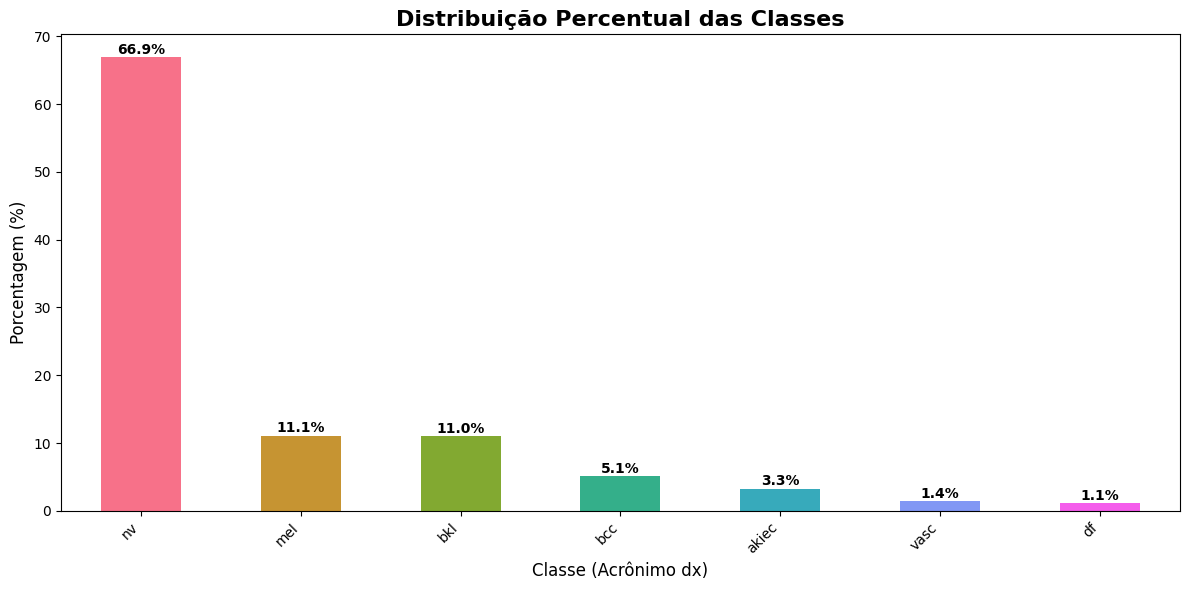

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Count by class using acronym (dx)
class_counts = metadata_df['dx'].value_counts()

# Convert to percentage
class_percent = (class_counts / class_counts.sum()) * 100

# Plot
class_percent.plot(kind='bar', ax=ax, color=sns.color_palette("husl", len(class_percent)))

ax.set_title('Distribuição Percentual das Classes', fontsize=16, fontweight='bold')
ax.set_xlabel('Classe (Acrônimo dx)', fontsize=12)
ax.set_ylabel('Porcentagem (%)', fontsize=12)
ax.set_xticklabels(class_percent.index, rotation=45, ha='right')

# Add percentage labels above bars
for i, v in enumerate(class_percent.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()   

Usando a coluna `dx`, foi calculada a contagem de imagens por classe e suas porcentagens.  
O gráfico de barras resultante mostra que o dataset é **fortemente desbalanceado**:

- a classe **`nv`** (nevos melanocíticos) concentra **mais da metade das imagens**;
- classes como **`df`** e **`vasc`** possuem pouco mais de uma centena de exemplos;
- as demais classes (**`akiec`**, **`bcc`**, **`bkl`**, **`mel`**) aparecem em quantidades intermediárias.

Esse desbalanceamento é problemático porque um modelo pode obter alta acurácia apenas “chutando” a classe majoritária.  

---

### 4. Distribuições globais dos metadados

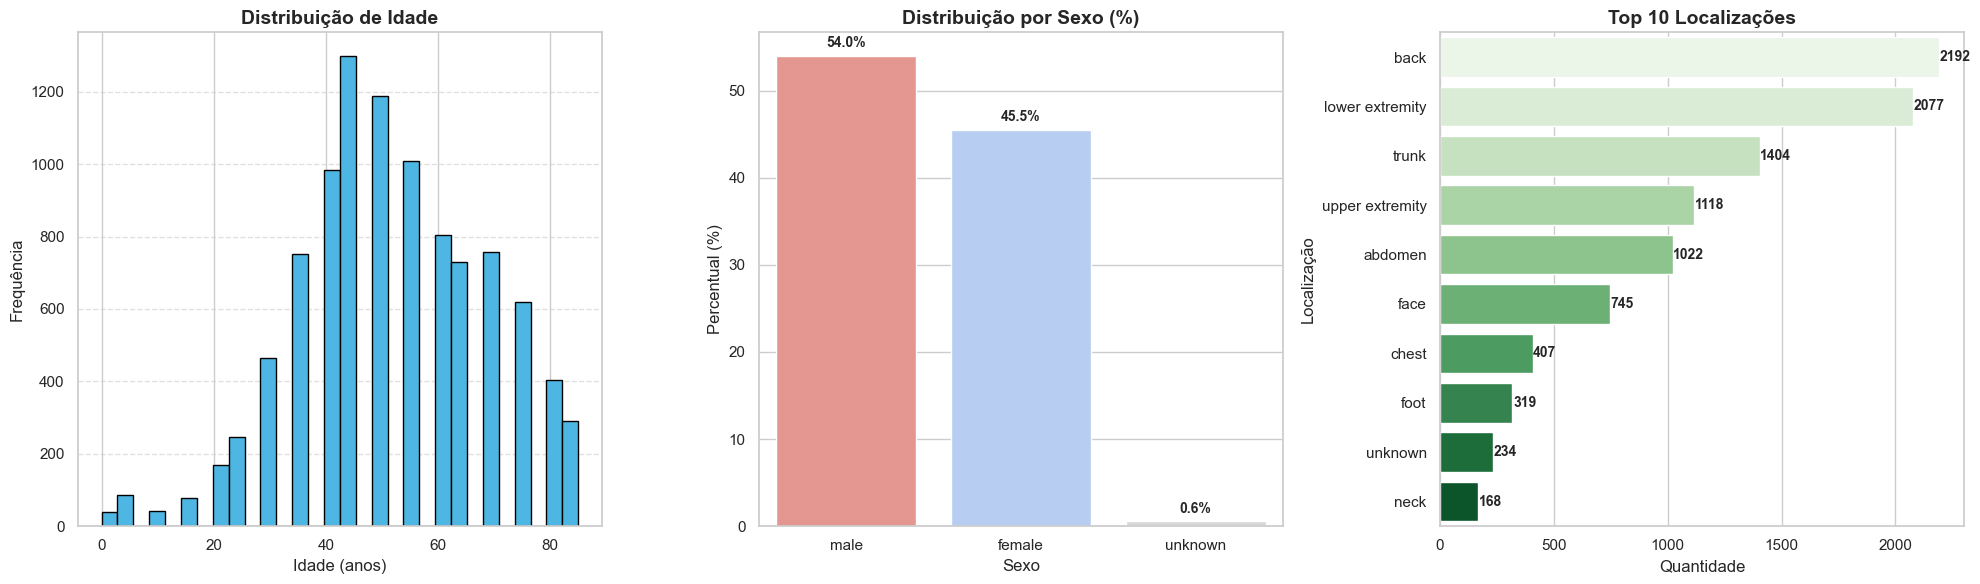

In [18]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# =========================================
# 1) Distribuição de Idade
# =========================================
axes[0].hist(metadata_df['age'].dropna(), bins=30, color='#4DB6E2', edgecolor='black')
axes[0].set_title('Distribuição de Idade', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Idade (anos)')
axes[0].set_ylabel('Frequência')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)



# =========================================
# 2) Distribuição por Sexo (em %)
# =========================================
sex_percent = metadata_df['sex'].value_counts(normalize=True) * 100
sex_df = sex_percent.reset_index()
sex_df.columns = ['sex', 'percent']

sns.barplot(
    data=sex_df,
    x='sex',
    y='percent',
    hue='sex',           
    palette=['#F28B82', '#AECBFA', '#D7D7D7'],
    legend=False,            
    ax=axes[1]
)

axes[1].set_title('Distribuição por Sexo (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Percentual (%)')
plt.setp(axes[1].get_xticklabels(), rotation=0)


# value labels
for i, v in enumerate(sex_percent.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=10, fontweight='bold')



# =========================================
# 3) Top 10 Localizações
# =========================================
top_loc = metadata_df['localization'].value_counts().head(10)
loc_df = top_loc.reset_index()
loc_df.columns = ['localization', 'count']

sns.barplot(
    data=loc_df,
    x='count',
    y='localization',
    hue='localization',   
    palette='Greens',
    legend=False,          
    ax=axes[2]
)

axes[2].set_title('Top 10 Localizações', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Quantidade')
axes[2].set_ylabel('Localização')

# labels
for i, v in enumerate(top_loc.values):
    axes[2].text(v + 3, i, str(v), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


Nesta etapa foi analisado a distribuição de **idade**, **sexo** e **localização anatômica** considerando todas as classes juntas.

- **Idade**  
  O histograma de `age` mostra idades aproximadamente entre 0 e 85 anos, com maior concentração em adultos de meia-idade e idosos.  
  Isso está de acordo com o comportamento esperado para doenças de pele, que tendem a ser mais frequentes em faixas etárias mais altas.

- **Sexo**  
  A variável `sex` é relativamente **balanceada** entre masculino e feminino, com leve predominância do sexo masculino e uma pequena fração de registros com sexo desconhecido.  
  Esse desbalanceamento leve não é crítico, mas vale ser monitorado caso os metadados sejam usados diretamente como entrada do modelo.

- **Localização anatômica**  
  A coluna `localization` é bastante **desigual**: regiões como *back*, *lower extremity* e *trunk* aparecem com muito mais frequência do que regiões raras como *ear*, *genital* ou *acral*.  
  Isso indica que o modelo pode ter mais dificuldade para generalizar bem em localizações pouco representadas.
---

### 5. Distribuições por classe (metadados condicionados ao diagnóstico)

In [19]:
def plot_demographics_for_class(df, class_code, class_label=None, n_top_loc=10):
    subset = df[df["dx"] == class_code]

    if subset.empty:
        print(f"⚠️ No samples for class '{class_code}'")
        return

    if class_label is None:
        class_label = class_code

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f"Demographic distribution for class: {class_label} ({class_code})",
        fontsize=16, fontweight="bold", y=1.02
    )

    # 1) Age distribution
    axes[0].hist(subset["age"].dropna(), bins=20, color="#4DB6E2", edgecolor="black")
    axes[0].set_title("Age distribution", fontweight="bold")
    axes[0].set_xlabel("Age (years)")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(axis="y", linestyle="--", alpha=0.6)

    # 2) Sex distribution (in %)
    sex_percent = subset["sex"].value_counts(normalize=True) * 100
    sex_df = sex_percent.reset_index()
    sex_df.columns = ["sex", "percent"]
    base_colors = ["#F28B82", "#AECBFA", "#D7D7D7"]
    palette = base_colors[:len(sex_df)]

    sns.barplot(
        data=sex_df,
        x="sex",
        y="percent",
        hue="sex",         
        palette=palette,
        legend=False,
        ax=axes[1]
    )
    axes[1].set_title("Sex distribution (%)", fontweight="bold")
    axes[1].set_xlabel("Sex")
    axes[1].set_ylabel("Percentage (%)")
    plt.setp(axes[1].get_xticklabels(), rotation=0)

    for i, v in enumerate(sex_df["percent"]):
        axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

    # 3) Top locations (counts)
    top_loc = subset["localization"].value_counts().head(n_top_loc)
    loc_df = top_loc.reset_index()
    loc_df.columns = ["localization", "count"]

    sns.barplot(
        data=loc_df,
        x="count",
        y="localization",
        hue="localization",
        palette="Greens",
        legend=False,
        ax=axes[2]
    )
    axes[2].set_title("Top locations", fontweight="bold")
    axes[2].set_xlabel("Count")
    axes[2].set_ylabel("Location")

    for i, v in enumerate(loc_df["count"]):
        axes[2].text(v + 0.5, i, str(v), va="center", fontsize=9, fontweight="bold")

    plt.tight_layout()
    plt.show()

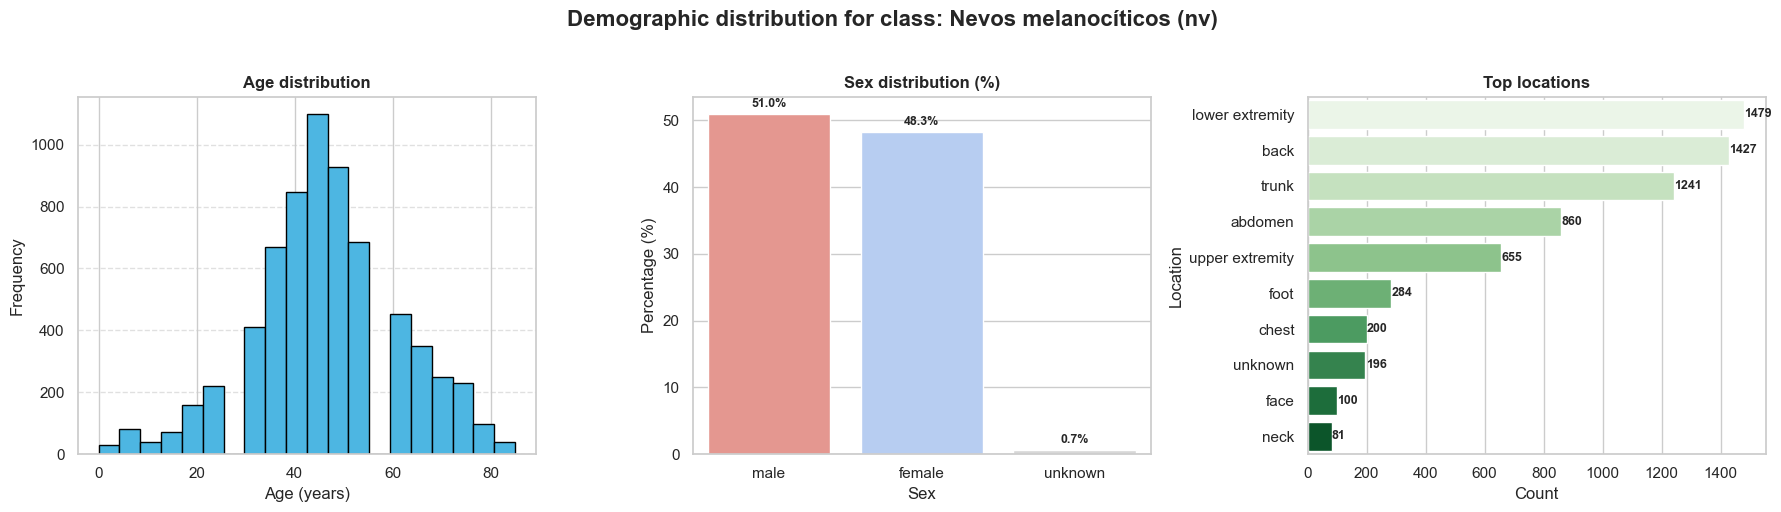

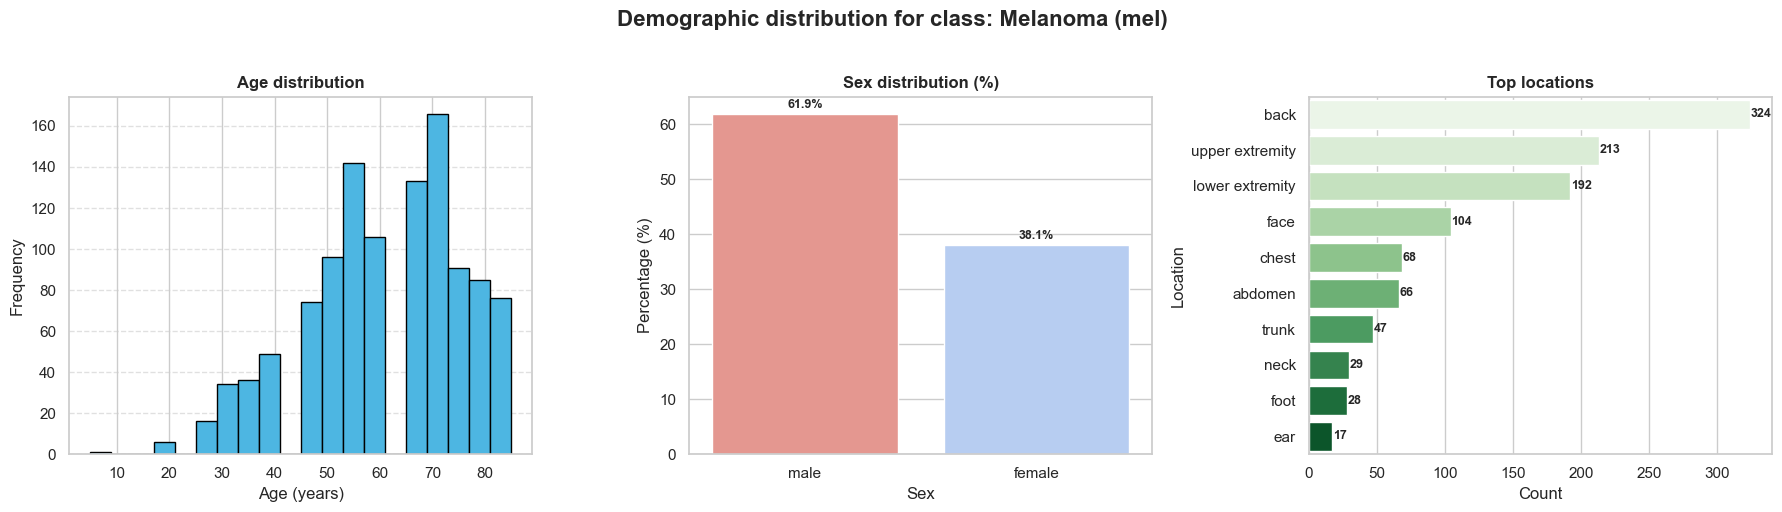

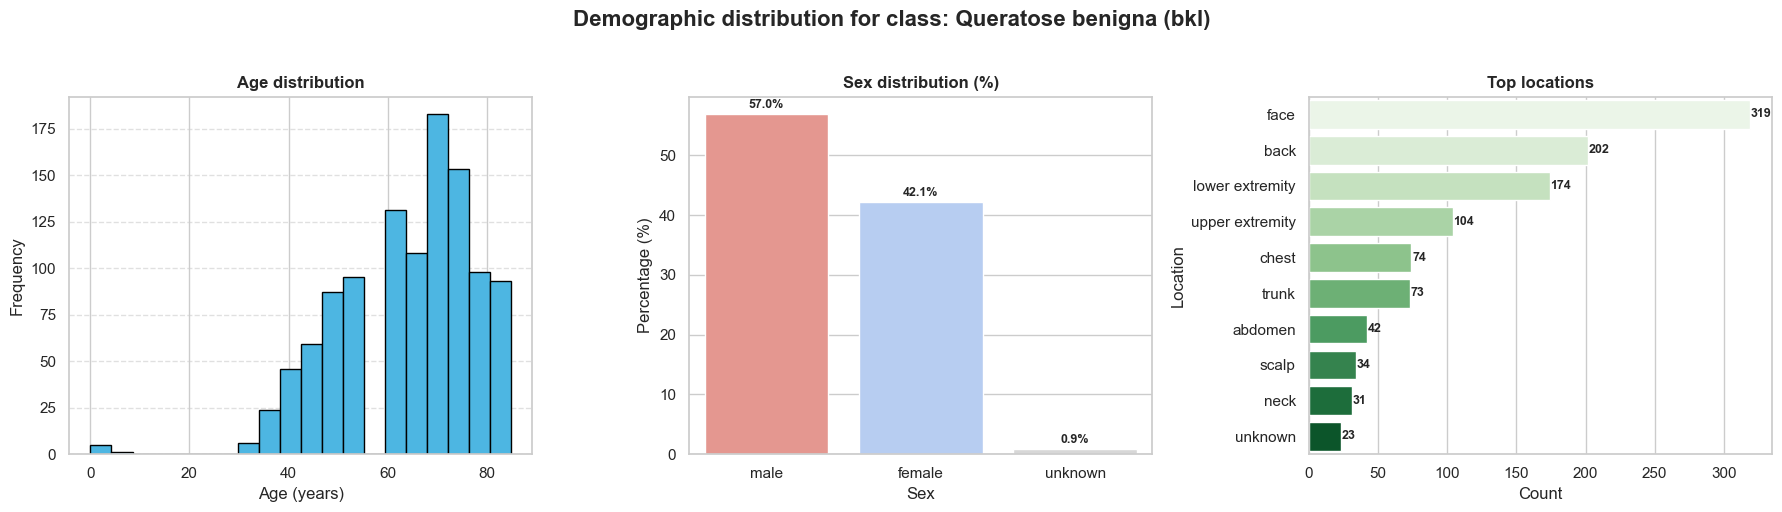

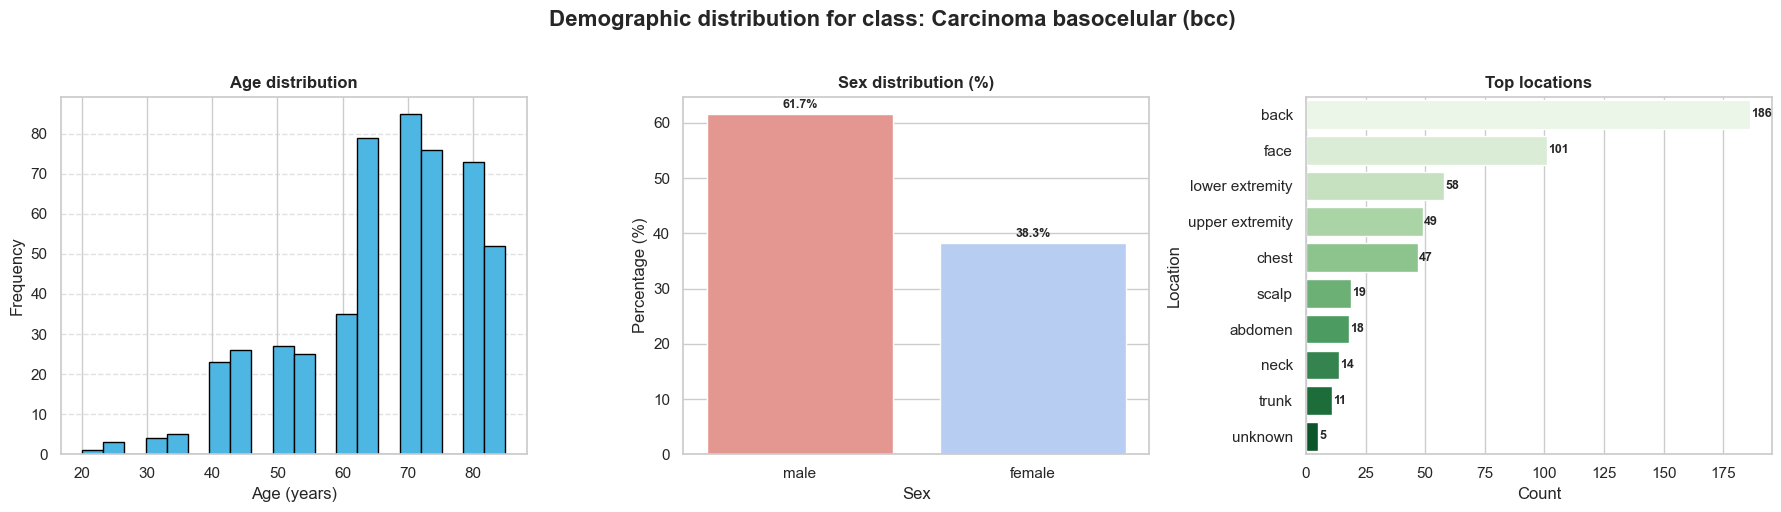

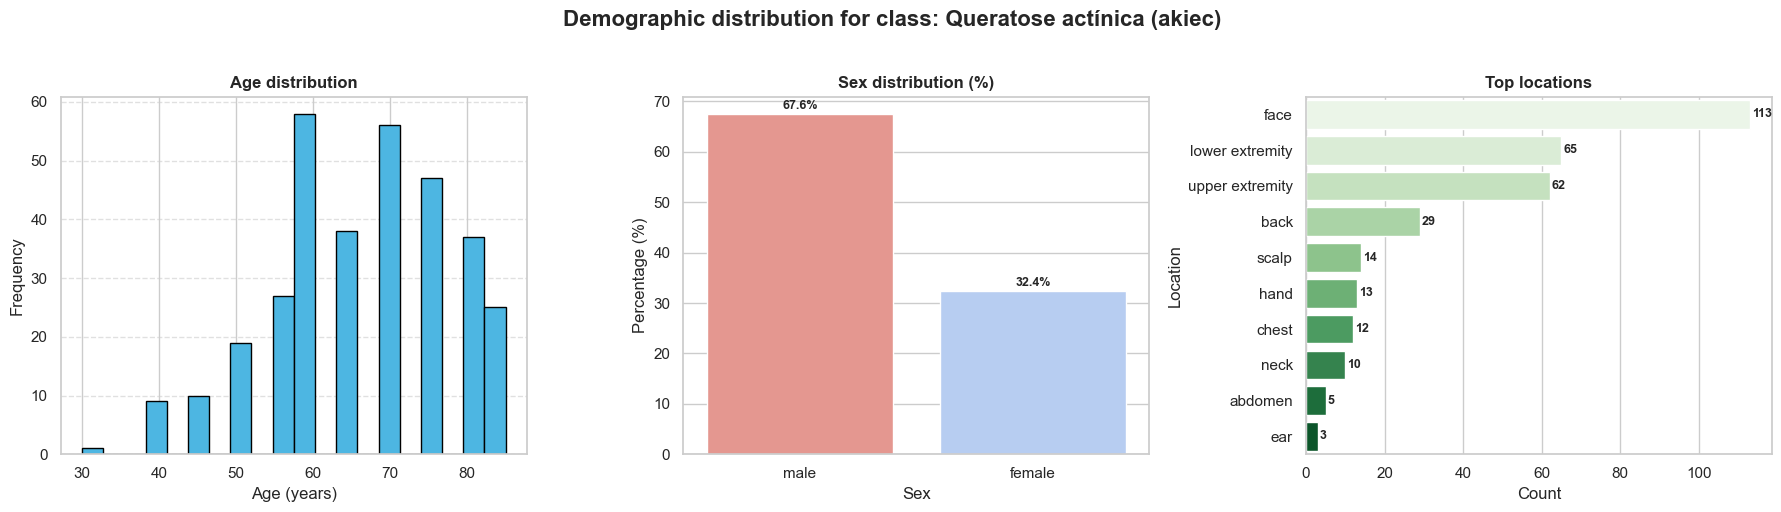

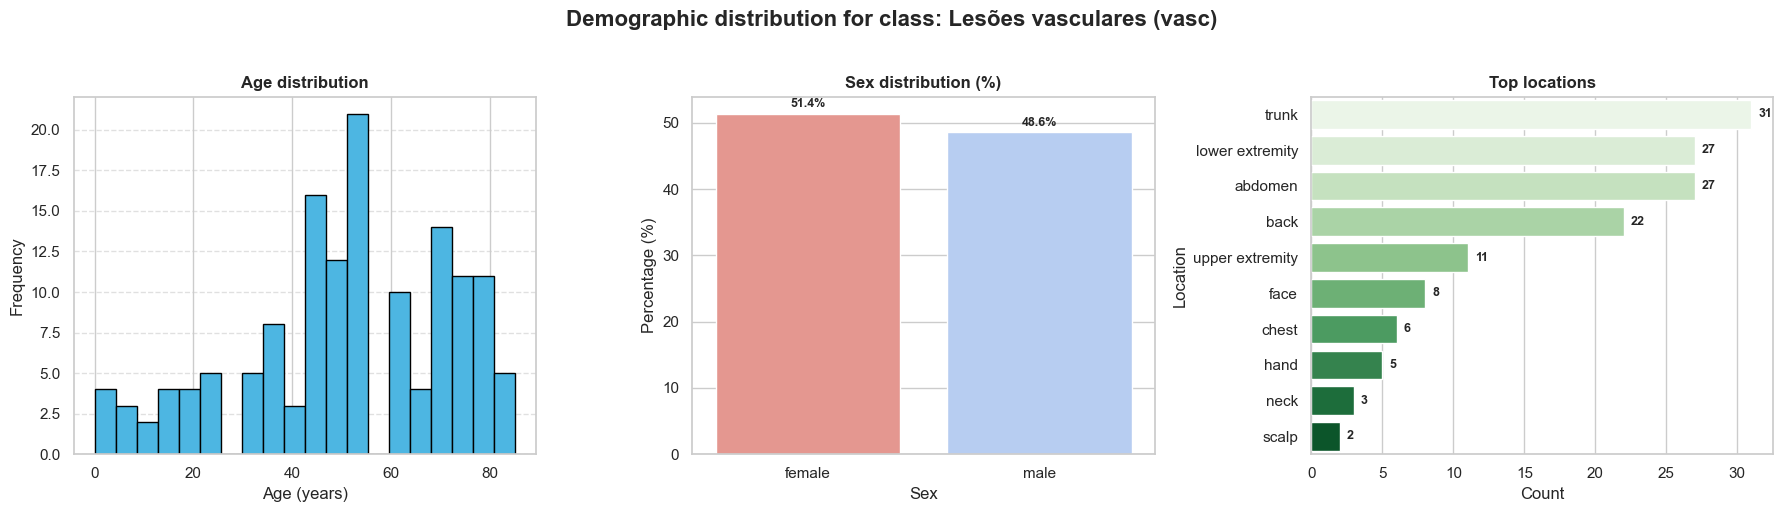

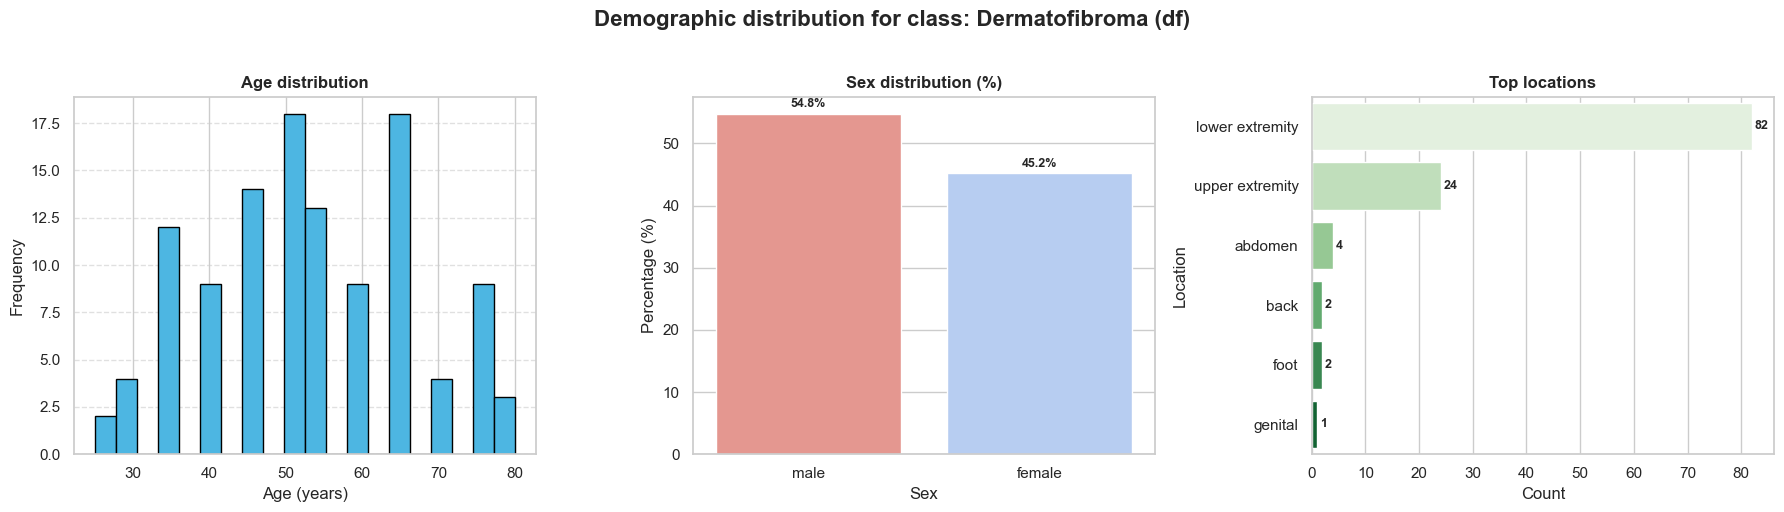

In [20]:
for cls in class_names: 
    plot_demographics_for_class(metadata_df, cls, class_names.get(cls, cls))

A função `plot_demographics_for_class` gera, para cada classe, gráficos com:

- histograma de idades;
- distribuição de sexo;
- distribuição das localizações anatômicas.

Essa análise **condicionada ao diagnóstico** ajuda a entender melhor o contexto clínico de cada classe:

- algumas lesões aparecem mais em determinadas faixas etárias;
- a proporção entre homens e mulheres pode variar entre diagnósticos;
- certas classes são mais comuns em regiões específicas do corpo (por exemplo, tronco/costas vs. extremidades).

Esses padrões mostram que os metadados trazem informação relevante e podem ser úteis em **modelos multimodais** (imagem + metadados).  
Ao mesmo tempo, evidenciam possíveis **vieses de amostragem**: se uma classe aparece quase sempre em uma região do corpo, o modelo pode aprender atalhos que não generalizam bem para outros cenários.

---

### 6. Análise das imagens

#### 6.1 Propriedades gerais das imagens

In [21]:
widths = []
heights = []
modes = []
formats = []
corrupted = []

for path in metadata_df["image_path"]:
    try:
        with Image.open(path) as img:
            widths.append(img.width)
            heights.append(img.height)
            modes.append(img.mode)
            formats.append(img.format)
    except:
        corrupted.append(path)

# Cria df com informações das imagens
img_info = pd.DataFrame({
    "width": widths,
    "height": heights,
    "mode": modes,
    "format": formats
})

print("Dimensões:")
print(img_info[["width", "height"]].describe(), "\n")

print("Modos de Cor:")
print(img_info["mode"].value_counts(), "\n")

print("Formatos das Imagens:")
print(img_info["format"].value_counts(), "\n")

if len(corrupted) > 0:
    print("⚠️ Imagens corrompidas encontradas:")
    for path in corrupted:
        print(" -", path)
else:
    print("Nenhuma imagem corrompida encontrada.")

Dimensões:
         width   height
count  10015.0  10015.0
mean     600.0    450.0
std        0.0      0.0
min      600.0    450.0
25%      600.0    450.0
50%      600.0    450.0
75%      600.0    450.0
max      600.0    450.0 

Modos de Cor:
mode
RGB    10015
Name: count, dtype: int64 

Formatos das Imagens:
format
JPEG    10015
Name: count, dtype: int64 

Nenhuma imagem corrompida encontrada.


A partir da coluna `image_path`, foram obtidos os dados:

- largura (`width`);
- altura (`height`);
- modo de cor (`mode`);
- formato (`format`).

No HAM10000, observa-se que:

- todas as imagens são **coloridas (RGB)**;
- possuem resolução aproximada de **600 × 450 pixels**;
- estão salvas, em geral, no formato **JPEG**.

Essa homogeneidade de tamanho e formato reduz o esforço de pré-processamento, pois permite definir uma etapa única de resize e normalização antes de alimentar a rede neural.

#### 6.2 Exemplos visuais por classe

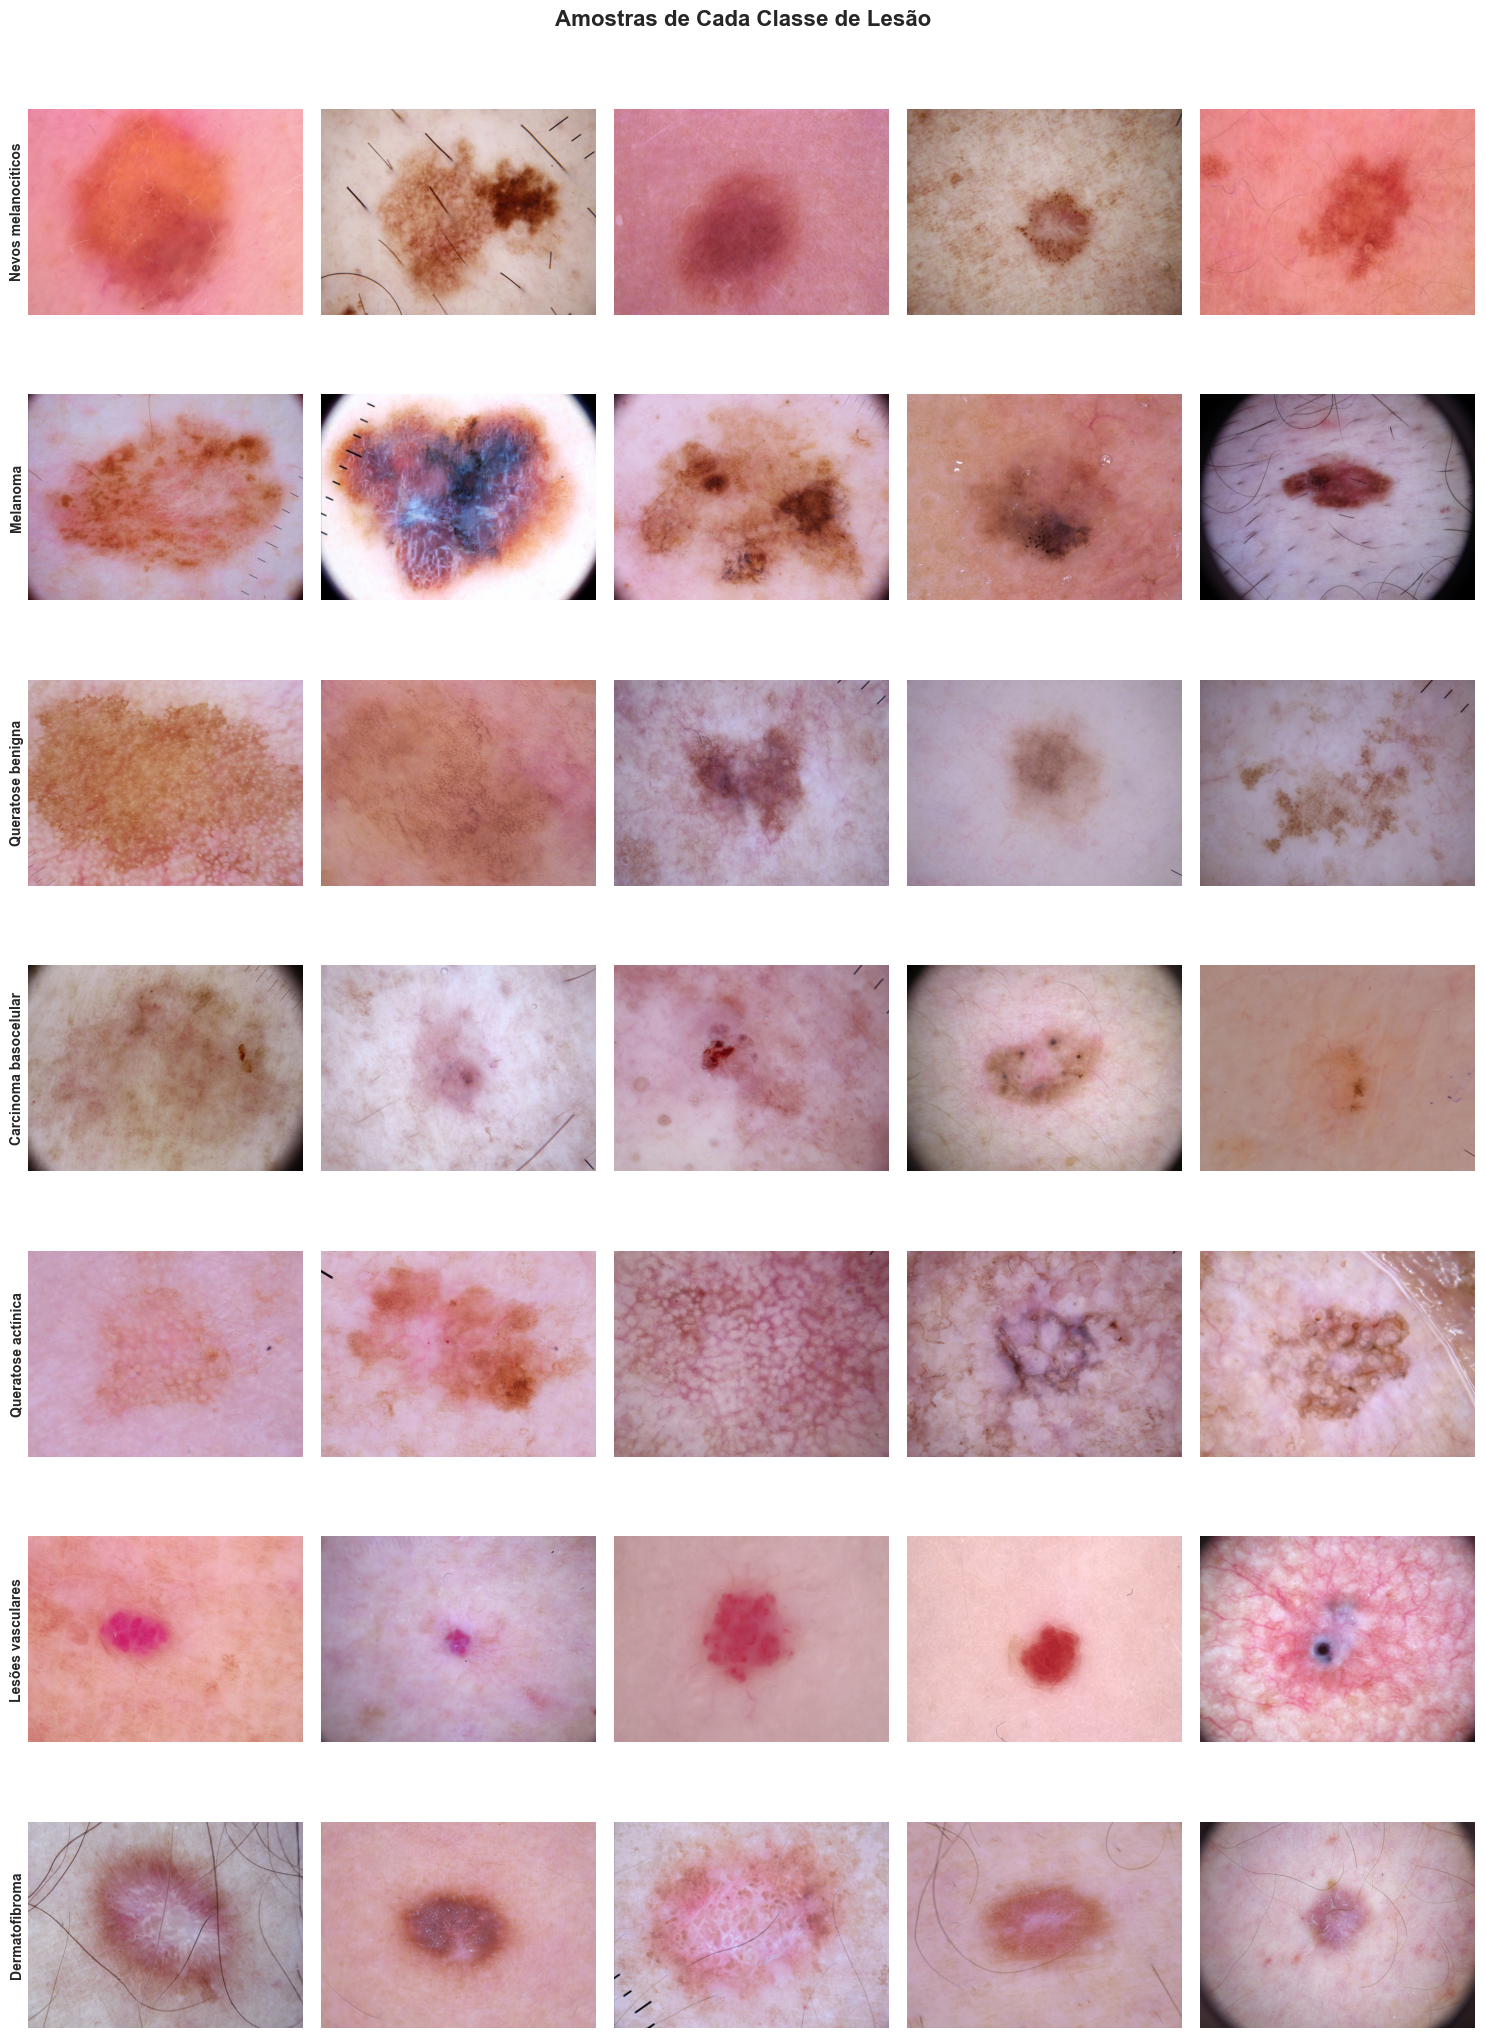

In [22]:
# Plotar 5 exemplos de cada classe
n_samples = 5
fig, axes = plt.subplots(num_classes, n_samples, figsize=(n_samples * 3, num_classes * 3))

for idx, (class_code, class_label) in enumerate(class_names.items()):
    # Pegar amostras aleatórias da classe
    class_df = metadata_df[metadata_df['dx'] == class_code]
    n_available = min(n_samples, len(class_df))
    class_samples = class_df.sample(n_available, random_state=SEED)
    
    for col, (_, row) in enumerate(class_samples.iterrows()):
        img = Image.open(row['image_path'])
        axes[idx, col].imshow(img)
        axes[idx, col].axis('off')
        
        # Adicionar título apenas na primeira coluna
        if col == 0:
            axes[idx, col].text(-10, img.size[1]//2, class_label, 
                              fontsize=10, fontweight='bold', 
                              rotation=90, va='center', ha='right')

plt.suptitle('Amostras de Cada Classe de Lesão', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

A partir das imagens é possível notar alguns padrões, dentre eles os três mais nítidos são:

- **Lesões vasculares (`vasc`)** tendem a apresentar coloração mais avermelhada e áreas bem delimitadas;
- **Melanomas (`mel`)** costumam ser mais escuros, com bordas irregulares e variação de tonalidade dentro da mesma lesão;
- **Dermatofibromas (`df`)** frequentemente exibem uma região central mais clara ou esbranquiçada;

---

## Preprocessamento

O objetivo desta etapa é transformar as imagens brutas do dataset em tensores normalizados e prontos para treinar a rede neural.

---

### Carregamento e Processamento de Imagem

In [23]:
print(f"Carregando e redimensionando {len(metadata_df)} imagens para {IMG_WIDTH}x{IMG_HEIGHT}...")
print("Isso pode levar alguns minutos...")

# Função para carregar e redimensionar imagem
def load_and_resize_image(path):
    try:
        img = Image.open(path)
        img = img.resize((IMG_WIDTH, IMG_HEIGHT))
        return np.array(img)
    except Exception as e:
        print(f"Erro ao carregar {path}: {e}")
        return None

# Carregar imagens
metadata_df['image_array'] = metadata_df['image_path'].apply(load_and_resize_image)

# Remover imagens que falharam
metadata_df = metadata_df.dropna(subset=['image_array'])

print(f"{len(metadata_df)} imagens carregadas com sucesso!")


Carregando e redimensionando 10015 imagens para 128x128...
Isso pode levar alguns minutos...
10015 imagens carregadas com sucesso!


In [24]:
# Verificar distribuição de tamanhos
shapes = metadata_df['image_array'].apply(lambda x: x.shape).value_counts()
print("Distribuição de shapes:")
print(shapes)



Distribuição de shapes:
image_array
(128, 128, 3)    10015
Name: count, dtype: int64


As imagens são carregadas a partir dos caminhos presentes no `metadata_df['image_path']`. Cada imagem é:

- Aberta e convertida para RGB;

- Redimensionada para IMG_WIDTH x IMG_HEIGHT pixels;

- Convertida para um numpy.array do tipo float32.

### Metadados

In [25]:
# 1) Seleciona colunas de metadados do próprio metadata_df
meta_cols = ["age", "sex", "localization"]
meta_cols = [c for c in meta_cols if c in metadata_df.columns]  # segurança

df_meta = metadata_df[meta_cols].copy()

# 2) Trata valores ausentes em 'age'
if "age" in df_meta.columns:
    df_meta["age"] = df_meta["age"].fillna(df_meta["age"].median())

# 3) One-hot das categóricas
cat_cols = [c for c in ["sex", "localization"] if c in df_meta.columns]

df_meta = pd.get_dummies(
    df_meta,
    columns=cat_cols,
    drop_first=True,
    dummy_na=True,   # se quiser uma categoria explícita para NA
)

# 4) Converte para array NumPy, alinhado com as linhas de metadata_df/X/y
meta_array = df_meta.values.astype("float32")
num_meta_features = meta_array.shape[1]

print("Shape do array de metadados:", meta_array.shape)
print("Número de features de metadados:", num_meta_features)

Shape do array de metadados: (10015, 19)
Número de features de metadados: 19


In [26]:
print(meta_array)

[[80.  1.  0. ...  0.  0.  0.]
 [80.  1.  0. ...  0.  0.  0.]
 [80.  1.  0. ...  0.  0.  0.]
 ...
 [40.  1.  0. ...  0.  0.  0.]
 [80.  1.  0. ...  0.  0.  0.]
 [70.  0.  0. ...  0.  0.  0.]]


---

### Train-Test Split

In [27]:
# Preparar features (X) e labels (y)
X = np.array(metadata_df['image_array'].tolist())
y = metadata_df['class_idx'].values

print("Shape dos dados:")
print(f"X: {X.shape}")
print(f"y: {y.shape}")


Shape dos dados:
X: (10015, 128, 128, 3)
y: (10015,)


A partir da coluna image_array, é construído o tensor de features:

- `X`: tensor de formato (N, 128, 128, 3), onde N é o número de imagens.

Os rótulos numéricos das classes são obtidos de `metadata_df['class_idx']`:

- `y`: vetor de tamanho N contendo o índice da classe de cada imagem.

Essa é a base para a divisão em treino, validação e teste.

In [28]:
X_train_full, X_test, y_train_full, y_test, meta_train_full, meta_test = train_test_split(
    X, y, meta_array,
    test_size=TEST_SIZE, 
    random_state=SEED,
    stratify=y
)

val_relative_size = VAL_SIZE / (1.0 - TEST_SIZE)

X_train, X_val, y_train, y_val, meta_train, meta_val = train_test_split(
    X_train_full, y_train_full, meta_train_full,
    test_size=val_relative_size,
    random_state=SEED,
    stratify=y_train_full
)

print("Divisão dos dados (imagens):")
print(f"    Treino:     {X_train.shape[0]:5d} imagens ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"    Validação:  {X_val.shape[0]:5d} imagens ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"    Teste:      {X_test.shape[0]:5d} imagens ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"    TOTAL:      {len(X):5d} imagens")

print("Metadados - shapes:")
print("    Treino:    ", meta_train.shape)
print("    Validação: ", meta_val.shape)
print("    Teste:     ", meta_test.shape)

Divisão dos dados (imagens):
    Treino:      7009 imagens (70.0%)
    Validação:   1503 imagens (15.0%)
    Teste:       1503 imagens (15.0%)
    TOTAL:      10015 imagens
Metadados - shapes:
    Treino:     (7009, 19)
    Validação:  (1503, 19)
    Teste:      (1503, 19)


Os dados são divididos em três subconjuntos, mantendo a proporção original das classes (estratificação):

- Treino: 70% das imagens

- Validação: 15% das imagens

- Teste: 15% das imagens

A divisão é feita em duas etapas:

- Separação inicial de teste a partir do conjunto completo;

- Divisão do restante entre treino e validação, usando uma fração relativa (para manter as porcentagens desejadas).

---

### Padronização

#### Imagens

In [29]:
# Calcular média e desvio padrão do conjunto de treino
X_train_mean = np.mean(X_train)
X_train_std = np.std(X_train)

print("Conjunto de treino (antes da normalização):")
print(f"Média: {X_train_mean:.2f}")
print(f"Desvio padrão: {X_train_std:.2f}")
print(f"Min: {X_train.min()}")
print(f"Max: {X_train.max()}")

# Padronização (z-score)
X_train = (X_train - X_train_mean) / X_train_std
X_val   = (X_val   - X_train_mean) / X_train_std
X_test  = (X_test  - X_train_mean) / X_train_std

print("Após normalização (padronização):")
print(f"Média: {X_train.mean():.6f}")
print(f"Desvio padrão: {X_train.std():.6f}")

Conjunto de treino (antes da normalização):
Média: 159.90
Desvio padrão: 46.65
Min: 0
Max: 255
Após normalização (padronização):
Média: -0.000000
Desvio padrão: 1.000000


#### Metadados

In [30]:
# --- 1) Identificar colunas numéricas ---
numeric_cols = ["age"]
numeric_cols = [c for c in numeric_cols if c in df_meta.columns]

# Índices das colunas numéricas dentro do vetor final
num_idx = df_meta.columns.get_indexer(numeric_cols)

# --- 2) Calcular média e desvio APENAS no conjunto de treino ---
meta_mean = meta_train[:, num_idx].mean(axis=0)
meta_std  = meta_train[:, num_idx].std(axis=0)

# Prevenir divisão por zero
meta_std = np.where(meta_std == 0, 1, meta_std)

# --- 3) Aplicar normalização em todos os conjuntos ---
meta_train[:, num_idx] = (meta_train[:, num_idx] - meta_mean) / meta_std
meta_val[:, num_idx]   = (meta_val[:, num_idx]   - meta_mean) / meta_std
meta_test[:, num_idx]  = (meta_test[:, num_idx]  - meta_mean) / meta_std

print("Normalização dos metadados concluída!")
print("Idade (treino) — média:", meta_train[:, num_idx].mean()," | desvio padrão:", meta_train[:, num_idx].std())


Normalização dos metadados concluída!
Idade (treino) — média: -9.728594e-08  | desvio padrão: 1.0


A normalização é feita **apenas com base no conjunto de treino**, evitando vazamento de informação entre os conjuntos.

1. Calcula-se a **média** e o **desvio padrão** de todos os pixels de `X_train`.
2. Cada conjunto (`X_train`, `X_val`, `X_test`) é padronizado usando: $X' = \frac{X - \mu_{\text{train}}}{\sigma_{\text{train}}}$

Após a padronização:

* O conjunto de **treino** passa a ter média ≈ 0 e desvio padrão ≈ 1;
* Os conjuntos de **validação** e **teste** são transformados usando os mesmos parâmetros do treino.


---

### One-Hot Encoding Labels Numéricos Imagens

In [31]:
# One-hot encoding
y_train_encoded = to_categorical(y_train, num_classes=num_classes)
y_val_encoded = to_categorical(y_val, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)

print("Exemplo de encoding:")
print(f"   Label original: {y_train[0]}")
print(f"   One-hot encoded: {y_train_encoded[0]}")

Exemplo de encoding:
   Label original: 5
   One-hot encoded: [0. 0. 0. 0. 0. 1. 0.]


Os rótulos numéricos (`y_train`, `y_val`, `y_test`) são convertidos para vetores *one-hot* utilizando `num_classes` como dimensão:

* `y_train_encoded`
* `y_val_encoded`
* `y_test_encoded`


---

## Módulos

Os módulos são trechos de códigos utilizados para o processamento, treinamento e demonstração dos dados.

---

### Modelos

In [32]:
def build_simple_cnn(input_shape, num_classes):
    """
    Cria uma CNN simples usada como primeiro modelo convolucional.

    Arquitetura:
    - Bloco 1: 2 convoluções (32 filtros) + MaxPooling + Dropout(0.25)
    - Bloco 2: 2 convoluções (64 filtros) + MaxPooling + Dropout(0.40)
    - Cabeça densa: Flatten + Dense(128) + Dropout(0.5) + Dense(num_classes, softmax)
    """
    model = Sequential()

    # --- Input layer ---
    model.add(Input(shape=input_shape))

    # Bloco 1
    model.add(Conv2D(32, kernel_size=(3, 3),
                     activation='relu', padding='same'))
    model.add(Conv2D(32, kernel_size=(3, 3),
                     activation='relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Bloco 2
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.40))

    # Cabeça densa
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    return model

In [33]:
def build_cnn_with_metadata(image_shape, metadata_dim, num_classes):
    """
    CNN multimodal que combina imagem + vetor de metadados.

    - Branch de imagem: CNN semelhante à CNN simples.
    - Branch de metadados: MLP pequeno (2 camadas densas).
    - Fusão: concatenação das duas representações e camadas densas finais.
    """

    # ----- Branch 1: IMAGEM -----
    img_input = Input(shape=image_shape, name="image_input")

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(img_input)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.40)(x)

    x = Flatten()(x)

    # ----- Branch 2: METADADOS -----
    meta_input = Input(shape=(metadata_dim,), name="metadata_input")

    m = Dense(64, activation='relu')(meta_input)
    m = Dropout(0.3)(m)
    m = Dense(32, activation='relu')(m)
    m = Dropout(0.3)(m)

    # ----- FUSÃO -----
    combined = Concatenate(name="fusion_concat")([x, m])

    z = Dense(128, activation='relu')(combined)
    z = Dropout(0.5)(z)
    output = Dense(num_classes, activation='softmax', name="output")(z)

    model = Model(inputs=[img_input, meta_input], outputs=output, name="cnn_with_metadata")
    return model

---

### Gráficos

In [34]:
def plot_history(history, model_name="Modelo"):
    """
    Plota as curvas de treino/validação de accuracy e loss.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Treino')
    axes[0].plot(history.history['val_accuracy'], label='Validação')
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(loc='best')
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], label='Treino')
    axes[1].plot(history.history['val_loss'], label='Validação')
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_ylabel('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(loc='best')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [35]:
def print_accuracy_summary(model_name, y_val_true, y_val_pred,
                           y_test_true, y_test_pred):
    """
    Imprime acurácia em validação e teste no mesmo formato
    usado para o modelo Dummy e para as CNNs.
    """
    acc_val = accuracy_score(y_val_true, y_val_pred)
    acc_test = accuracy_score(y_test_true, y_test_pred)
    print("=" * 70)
    print(f"{model_name}:")
    print("=" * 70)
    print(f"Acurácia Validação: {acc_val * 100:.2f}%")
    print(f"Acurácia Teste:     {acc_test * 100:.2f}%")


def plot_confusion_and_report(y_true, y_pred, class_names, model_name):
    """
    Plota a matriz de confusão e imprime o classification_report
    com o mesmo estilo das seções do notebook.
    """
    # Matriz de confusão
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=list(class_names.keys()),
        yticklabels=list(class_names.keys()),
    )
    plt.title(f'Matriz de Confusão - {model_name}', fontsize=14, fontweight='bold')
    plt.ylabel('Classe Verdadeira')
    plt.xlabel('Classe Predita')
    plt.tight_layout()
    plt.show()

    # Relatório de classificação
    print(f"RELATÓRIO DE CLASSIFICAÇÃO - {model_name.upper()}:")
    print("=" * 80)
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=list(class_names.values()),
            digits=4,
            zero_division=0
        )
    )
    print("=" * 80)

---

## Modelo Dummy

Antes de treinar modelos mais complexos, é importante definir um **baseline**. Como baseline foi utilizado o **modelo dummy**, que ignora completamente as imagens e sempre prediz a **classe mais frequente** do conjunto de treino. Esse modelo serve como referência mínima: outroso modelos precisam performar melhor do que ele, especialmente nas classes minoritárias.

---

### Como o modelo Dummy funciona?

Utilizamos o `DummyClassifier` do `sklearn` com a estratégia:

- `strategy='most_frequent'`: o classificador aprende apenas qual é a classe que mais aparece em `y_train` e passa a sempre retornar essa classe,
independentemente da entrada

Esse comportamento é adequado para evidenciar o **desbalanceamento do dataset**: se uma única classe é muito comum, o modelo pode ter uma acurácia razoável,
mas será péssimo nas demais classes.

---


### Treinamento e Avaliação do Dummy

In [38]:
# Modelo dummy que sempre prediz a classe majoritária
dummy_model = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy_model.fit(X_train, y_train)

print("Modelo dummy treinado!")

Modelo dummy treinado!


In [40]:
# Predições
y_pred_val = dummy_model.predict(X_val)
y_pred_test = dummy_model.predict(X_test)

# Acurácias
print_accuracy_summary("Dummy Classifier", y_val, y_pred_val, y_test, y_pred_test)

Dummy Classifier:
Acurácia Validação: 66.93%
Acurácia Teste:     66.93%


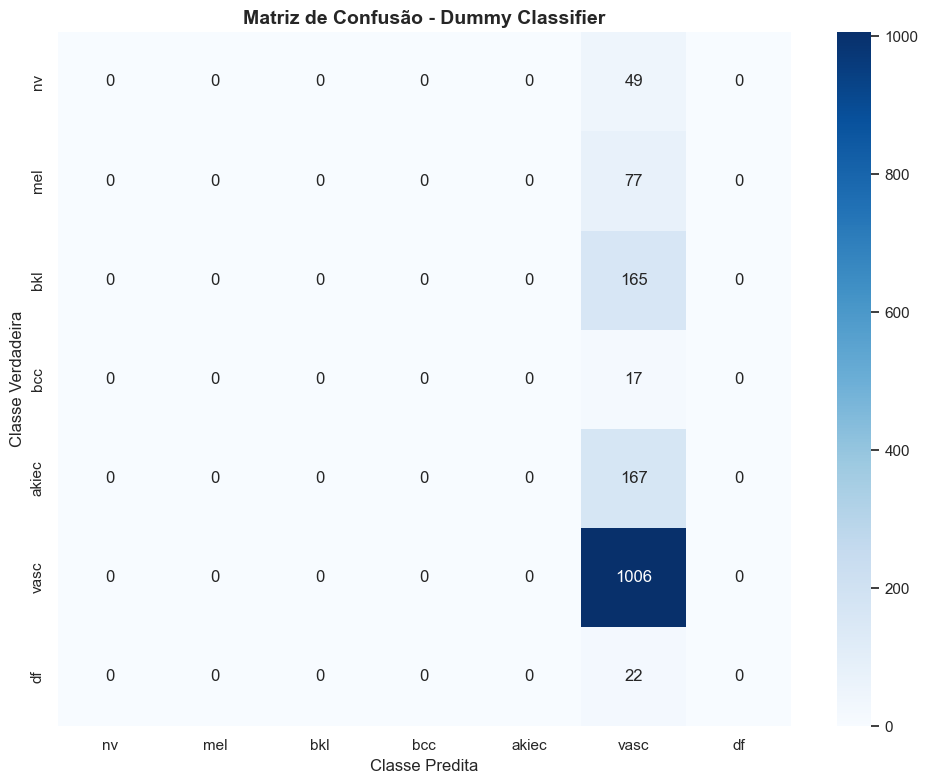

RELATÓRIO DE CLASSIFICAÇÃO - DUMMY CLASSIFIER:
                       precision    recall  f1-score   support

  Nevos melanocíticos     0.0000    0.0000    0.0000        49
             Melanoma     0.0000    0.0000    0.0000        77
    Queratose benigna     0.0000    0.0000    0.0000       165
Carcinoma basocelular     0.0000    0.0000    0.0000        17
   Queratose actínica     0.0000    0.0000    0.0000       167
    Lesões vasculares     0.6693    1.0000    0.8019      1006
       Dermatofibroma     0.0000    0.0000    0.0000        22

             accuracy                         0.6693      1503
            macro avg     0.0956    0.1429    0.1146      1503
         weighted avg     0.4480    0.6693    0.5367      1503



In [41]:
plot_confusion_and_report(y_test, y_pred_test, class_names, "Dummy Classifier")

O modelo dummy alcançou cerca de **66–67%** de acurácia simplesmente por sempre predizer a classe mais frequente.

**Pontos importantes:**

- A matriz de confusão mostra que a maior parte dos acertos está concentrada na classe majoritária
- Apesar da acurácia as classes raras **não são reconhecidas**

A partir deste baseline, todos os modelos subsequentes devem superar claramente esse desempenho, principalmente em termos de equilíbrio entre as classes.


---

## Redes Neurais Convolucionais (CNNs)

Nesta seção foram treinados modelos de **Redes Neurais Convolucionais (CNNs)** para classificar as imagens de lesões de pele.

Antes de mostrar os modelos, será explicado rapidamente o que é uma CNN e como ela foi declarada neste projeto.

---

### 1. Conceito

Uma **CNN (Convolutional Neural Network)** é um tipo de rede neural projetada para trabalhar com **dados em grade**, como imagens. No nosso problema, cada imagem de pele é representada como um tensor `(altura, largura, canais)`, por exemplo `(IMG_HEIGHT, IMG_WIDTH, CHANNELS)`.

Os principais blocos de uma CNN são:

1. **Camadas convolucionais (`Conv2D`)**  
   - Aplicam filtros (kernels) que “varrem” a imagem
   - Cada filtro aprende a detectar padrões locais
   - A saída são **mapas de ativação** que destacam regiões onde esses padrões foram encontrados

2. **Função de ativação (`ReLU`)**  
   - Introduz não-linearidade, permitindo que a rede aprenda relações mais complexas
   - Mantém apenas valores positivos, o que ajuda na estabilidade do treino
   - Evita "vanishing gradient"

    $\text{ReLU}(z) =
    \begin{cases}
    0, & \text{if } z < 0 \\
    z, & \text{if } z \ge 0 \\
    \end{cases}$

3. **Camadas de pooling (`MaxPooling2D`)**  
   - Reduzem a resolução espacial dos mapas de ativação

4. **Dropout**  
   - Zera aleatoriamente uma fração das ativações durante o treino;
   - Ajuda a evitar **overfitting**, fazendo a rede depender menos de neurônios específicos.

5. **Flatten + camadas densas (`Dense`)**  
   - Depois de várias convoluções/pooling, os mapas de ativação são “achatados” em um vetor 1D (`Flatten`)
   - Esse vetor é passado por camadas densas que funcionam como um classificador tradicional
   - A última camada usa `softmax` para produzir uma **distribuição de probabilidades** sobre as `num_classes` de lesões

    $\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$

---

### 2. Declaração CNN

Para a maioria dos casos foi utilizada a API `Sequential` do Keras para criar o seguinte modelo:

- `input_shape = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)` define o formato das imagens;
- Dois blocos convolucionais:
  - Bloco 1: duas `Conv2D(32, 3×3)` + `MaxPooling2D` + `Dropout(0.25)`
  - Bloco 2: duas `Conv2D(64, 3×3)` + `MaxPooling2D` + `Dropout(0.40)`
- Cabeça densa:
  - `Flatten()` → `Dense(128, activation='relu')` → `Dropout(0.5)` → `Dense(num_classes, activation='softmax')`

---

### 3. CNN Simples

Nesta primeira arquitetura convolucional usamos uma CNN “padrão”, sem técnicas explícitas de balanceamento. O objetivo é verificar quanto já ganhamos em relação ao modelo dummy apenas explorando a estrutura espacial das imagens.

- Entrada do Modelo: imagens redimensionadas e padronizadas

---

#### Implementação

In [69]:
# 1. Construção do modelo
input_shape = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)
model_cnn_simple = build_simple_cnn(input_shape, num_classes)
model_cnn_simple.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,455,207 (32.25 MB)

 Trainable params: 8,455,207 (32.25 MB)

 Non-trainable params: 0 (0.00 B)

In [72]:
# 2. Compilação
optimizer = Adam(learning_rate=0.0005)

model_cnn_simple.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

# Earliness stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
)

# Callback para reduzir LR quando a validação "satura"
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    verbose=1,
    factor=0.5,
    min_lr=1e-5,
)

print("CNN Simples compilada!")

CNN Simples compilada!


In [73]:
# 3. Treinamento
history_cnn_simple = model_cnn_simple.fit(
    X_train, y_train_encoded,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val_encoded),
    callbacks=[learning_rate_reduction, early_stopping],
    verbose=1,
)
print("CNN Simples treinada!")

Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 32s 140ms/step - accuracy: 0.6653 - loss: 0.9897 - val_accuracy: 0.6813 - val_loss: 0.8941 - learning_rate: 5.0000e-04
Epoch 2/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 31s 142ms/step - accuracy: 0.6845 - loss: 0.8728 - val_accuracy: 0.6979 - val_loss: 0.8314 - learning_rate: 5.0000e-04
Epoch 3/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 32s 147ms/step - accuracy: 0.7048 - loss: 0.8084 - val_accuracy: 0.7046 - val_loss: 0.7964 - learning_rate: 5.0000e-04
Epoch 4/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 33s 151ms/step - accuracy: 0.7172 - loss: 0.7667 - val_accuracy: 0.7239 - val_loss: 0.7512 - learning_rate: 5.0000e-04
Epoch 5/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 33s 151ms/step - accuracy: 0.7371 - loss: 0.7162 - val_accuracy: 0.7379 - val_loss: 0.7464 - learning_rate: 5.0000e-04
Epoch 6/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 33s 152ms/step - accuracy: 0.7489 - loss: 0.6745 - val_accuracy: 0.7372 - val_loss: 0.7421 - learning_rate: 5.0000e-04
Epoch 7/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 34s 15

In [74]:
model_cnn_simple.save("models/cnn/simple.keras")
print("CNN Simples salva!")

CNN Simples salva!


---

#### Resultados

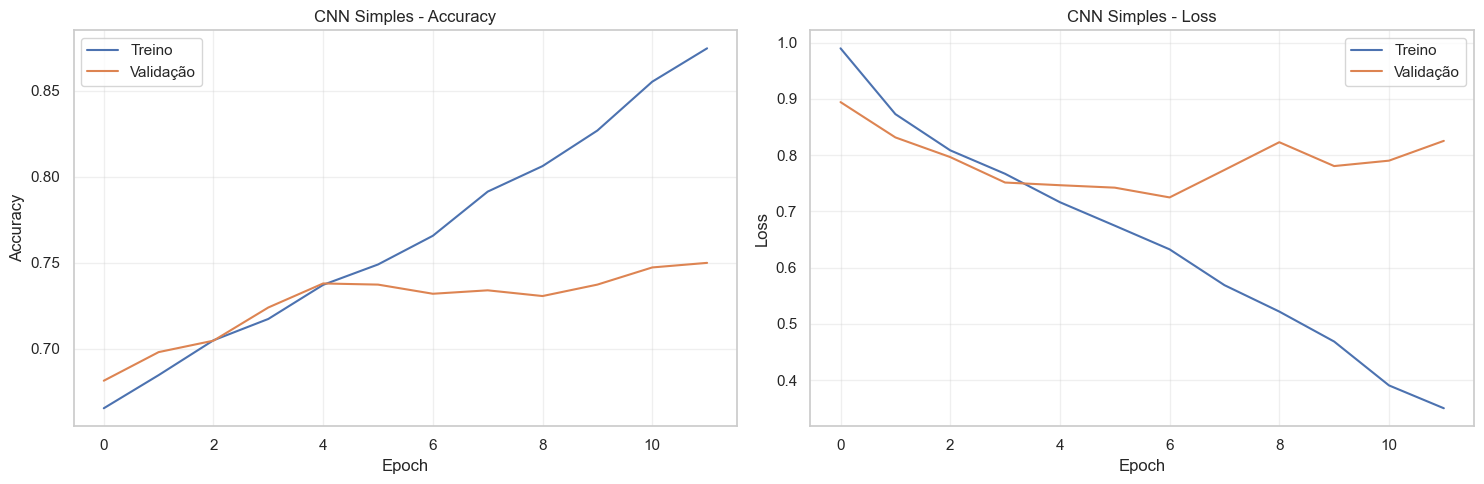

In [75]:
# 4. Curvas de treino/validação
plot_history(history_cnn_simple, model_name="CNN Simples")

A rede apresenta um aprendizado consistente no conjunto de treino: a acurácia cresce de forma contínua até cerca de 87%, enquanto o loss cai progressivamente. No entanto, após poucas épocas, observa-se uma estagnação clara no conjunto de validação.

Alguns pontos importantes:

- A acurácia de validação estabiliza entre 73% e 75%, sem acompanhar o crescimento observado no treino.

- O loss de validação diminui nas primeiras épocas, mas logo passa a oscilar e volta a crescer após aproximadamente a 8ª época.

- Há um gap crescente entre treino e validação, tanto em acurácia quanto em loss, evidenciando overfitting.

In [76]:
simple_model = load_model("models/cnn/simple.keras")
print("CNN Simples carregada!")

CNN Simples carregada!


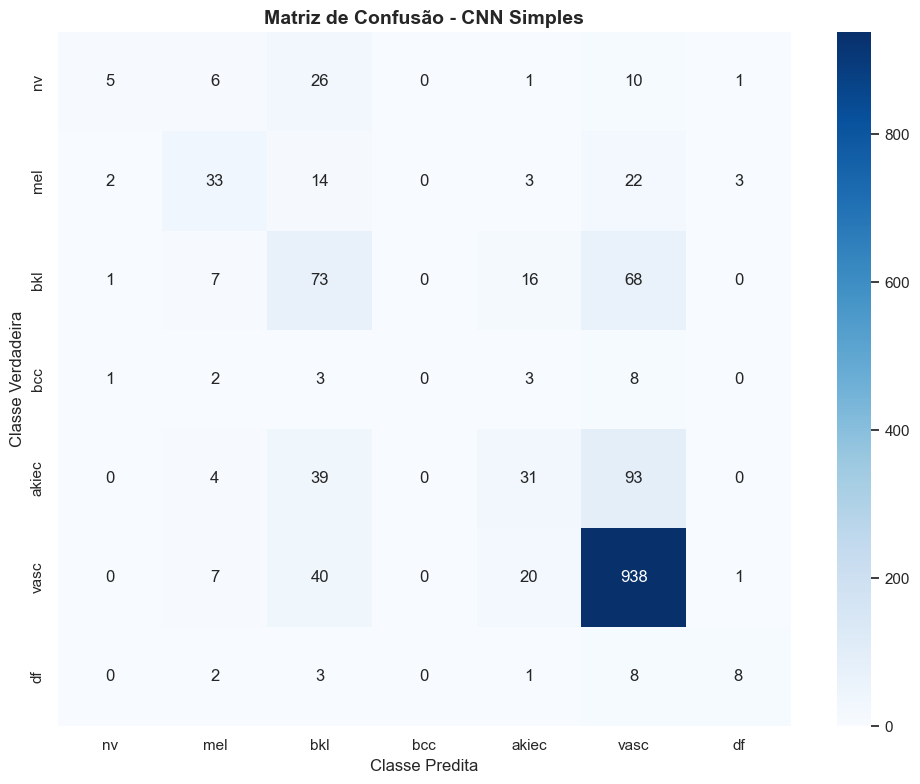

RELATÓRIO DE CLASSIFICAÇÃO - CNN SIMPLES:
                       precision    recall  f1-score   support

  Nevos melanocíticos     0.5556    0.1020    0.1724        49
             Melanoma     0.5410    0.4286    0.4783        77
    Queratose benigna     0.3687    0.4424    0.4022       165
Carcinoma basocelular     0.0000    0.0000    0.0000        17
   Queratose actínica     0.4133    0.1856    0.2562       167
    Lesões vasculares     0.8178    0.9324    0.8713      1006
       Dermatofibroma     0.6154    0.3636    0.4571        22

             accuracy                         0.7239      1503
            macro avg     0.4731    0.3507    0.3768      1503
         weighted avg     0.6886    0.7239    0.6926      1503



In [78]:
# 5. Avaliação em teste: matriz de confusão + relatório
y_pred_cnn_simple = simple_model.predict(X_test, verbose=0)
y_pred_classes_cnn_simple = np.argmax(y_pred_cnn_simple, axis=1)

plot_confusion_and_report(
    y_true=y_test,
    y_pred=y_pred_classes_cnn_simple,
    class_names=class_names,
    model_name="CNN Simples",
)

1. **Métricas globais**

- Acurácia geral: **72,39%**, acima do Dummy Classifier (66,93%), indicando que a rede apreende padrões visuais relevantes além da classe majoritária.
- Macro avg (média simples entre as classes):
  - recall ≈ 0,35 e F1 ≈ 0,37 — desempenho global baixo quando todas as classes têm o mesmo peso.
- Weighted avg:
  - recall ≈ 0,72, F1 ≈ 0,69 — puxado para cima devido ao forte desempenho na classe majoritária.

Em síntese: o modelo supera o baseline simples, mas sofre com generalização fraca e forte influência do desbalanceamento da base.

2. **Métricas por classe**

| Classe                | support | precision | recall | f1-score | Comentário |
|----------------------|---------|-----------|--------|----------|------------|
| Nevos melanocíticos   | 49  | 0.56 | 0.10 | 0.17 | A rede identifica poucos casos reais; recall muito baixo. |
| Melanoma              | 77  | 0.54 | 0.43 | 0.48 | Acerta um pouco menos da metade dos melanomas; desempenho moderado. |
| Queratose benigna     | 165 | 0.37 | 0.44 | 0.40 | Resultados medianos |
| Carcinoma basocelular | 17  | 0.00 | 0.00 | 0.00 | Não detecta nenhum caso real; desempenho equivalente ao dummy. |
| Queratose actínica    | 167 | 0.41 | 0.18 | 0.25 | A maior parte das queratoses actínicas é classificada como outras classes. |
| Lesões vasculares     | 1006| 0.82 | 0.93 | 0.87 | Classe dominante; desempenho muito alto devido ao desbalanceamento. |
| Dermatofibroma        | 22  | 0.62 | 0.36 | 0.46 | Quando previsto é geralmente correto, porém muitos casos reais passam despercebidos. |

Observa-se desempenho consistentemente fraco nas classes minoritárias e razoável apenas nas classes com mais amostras. A rede aproxima-se do comportamento do dummy nas classes com poucos exemplos, sem conseguir capturar suas características visuais específicas.

3. **Conclusão**

A CNN simples apresenta desempenho superior ao Dummy Classifier, aprendendo padrões relevantes no conjunto de dados. No entanto, sofre com overfitting, forte viés para a classe majoritária e baixa sensibilidade nas classes menos representadas, incluindo classes clinicamente relevantes, como carcinoma basocelular e nevos melanocíticos. Os resultados indicam que, apesar do avanço em relação ao baseline, o modelo ainda generaliza pouco e não é adequado para uso em cenários reais sem melhorias adicionais.

---

### 4. CNN com Pesos de Classes

Com o intuito de mitigar o problema do desbalanceamento do dataset observado no modelo anterior, a arquitetura atual implementou **pesos de classe** (*class weights*).

> “Erros em classes raras são mais graves do que erros em classes comuns.”

Assim, a loss passa a penalizar mais os erros nas classes com poucos exemplos, incentivando o modelo a prestar mais atenção nelas.

---

#### Como os pesos de classe são calculados?

Foi utilizada a função `compute_class_weight` do `sklearn`, com a estratégia `balanced`. A fórmula básica é:

$w_c = \frac{N}{n_c \cdot K}$

onde:

- $( N )$ é o número total de amostras,
- $( K )$ é o número de classes,
- $( n_c )$ é o número de amostras da classe $( c )$,
- $( w_c )$ é o peso atribuído à classe $( c )$.

Intuição:

- quanto **menor** $( n_c )$, **maior** será $( w_c )$;
- classes raras recebem pesos grandes, classes comuns recebem pesos menores.

Esses pesos são passados ao `model.fit` no argumento `class_weight`, que faz com que a função de loss “cobre mais caro” os erros nas classes minoritárias.


In [85]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train,
)

# Converte para dicionário {classe: peso} no formato que o Keras espera
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
print("Pesos das classes:")

for idx, (code, name) in enumerate(class_names.items()):
    count = (y_train == idx).sum()
    weight = class_weight_dict[idx]
    print(f"  Classe {idx} ({code:6s}): peso = {weight:.2f} ({count:4d} imagens)")

Pesos das classes:
  Classe 0 (nv    ): peso = 4.37 ( 229 imagens)
  Classe 1 (mel   ): peso = 2.78 ( 360 imagens)
  Classe 2 (bkl   ): peso = 1.30 ( 769 imagens)
  Classe 3 (bcc   ): peso = 12.52 (  80 imagens)
  Classe 4 (akiec ): peso = 1.29 ( 779 imagens)
  Classe 5 (vasc  ): peso = 0.21 (4693 imagens)
  Classe 6 (df    ): peso = 10.11 (  99 imagens)


---

#### Implementação

A única diferença em relação à CNN simples está na maneira como a loss é calculada durante o treino: agora ela leva em conta os **pesos de classe** definidos acima.

In [86]:
# 1. Construção do modelo
input_shape = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)
model_cnn_weights = build_simple_cnn(input_shape, num_classes)

model_cnn_weights.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,455,207 (32.25 MB)

 Trainable params: 8,455,207 (32.25 MB)

 Non-trainable params: 0 (0.00 B)

In [87]:
# 1. Compilação com LR ajustado
optimizer = Adam(learning_rate=0.0005)

model_cnn_weights.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

# Earliness stopping
early_stopping_weights = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
)


learning_rate_reduction_weights = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    verbose=1,
    factor=0.5,
    min_lr=1e-6
)

print("CNN com Pesos de Classe compilada!")

CNN com Pesos de Classe compilada!


In [88]:
# 3. Treinamento
history_cnn_weights = model_cnn_weights.fit(
    X_train, y_train_encoded,
    batch_size=BATCH_SIZE,
    epochs=30,
    validation_data=(X_val, y_val_encoded),
    class_weight=class_weight_dict,
    callbacks=[learning_rate_reduction_weights, early_stopping_weights],
    verbose=1,
)

Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 32s 143ms/step - accuracy: 0.4747 - loss: 1.8801 - val_accuracy: 0.3912 - val_loss: 1.6965 - learning_rate: 5.0000e-04
Epoch 2/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 31s 142ms/step - accuracy: 0.4434 - loss: 1.7011 - val_accuracy: 0.4158 - val_loss: 1.5728 - learning_rate: 5.0000e-04
Epoch 3/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 31s 142ms/step - accuracy: 0.4474 - loss: 1.5490 - val_accuracy: 0.5090 - val_loss: 1.3955 - learning_rate: 5.0000e-04
Epoch 4/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 31s 142ms/step - accuracy: 0.4752 - loss: 1.4577 - val_accuracy: 0.4930 - val_loss: 1.3196 - learning_rate: 5.0000e-04
Epoch 5/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 31s 142ms/step - accuracy: 0.4901 - loss: 1.3334 - val_accuracy: 0.5170 - val_loss: 1.1778 - learning_rate: 5.0000e-04
Epoch 6/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 31s 142ms/step - accuracy: 0.5029 - loss: 1.2738 - val_accuracy: 0.5243 - val_loss: 1.2273 - learning_rate: 5.0000e-04
Epoch 7/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 31s 14

In [89]:
model_cnn_weights.save("models/cnn/class_weights.keras")
print("CNN com Pesos salva!")

CNN com Pesos salva!


#### Resultados

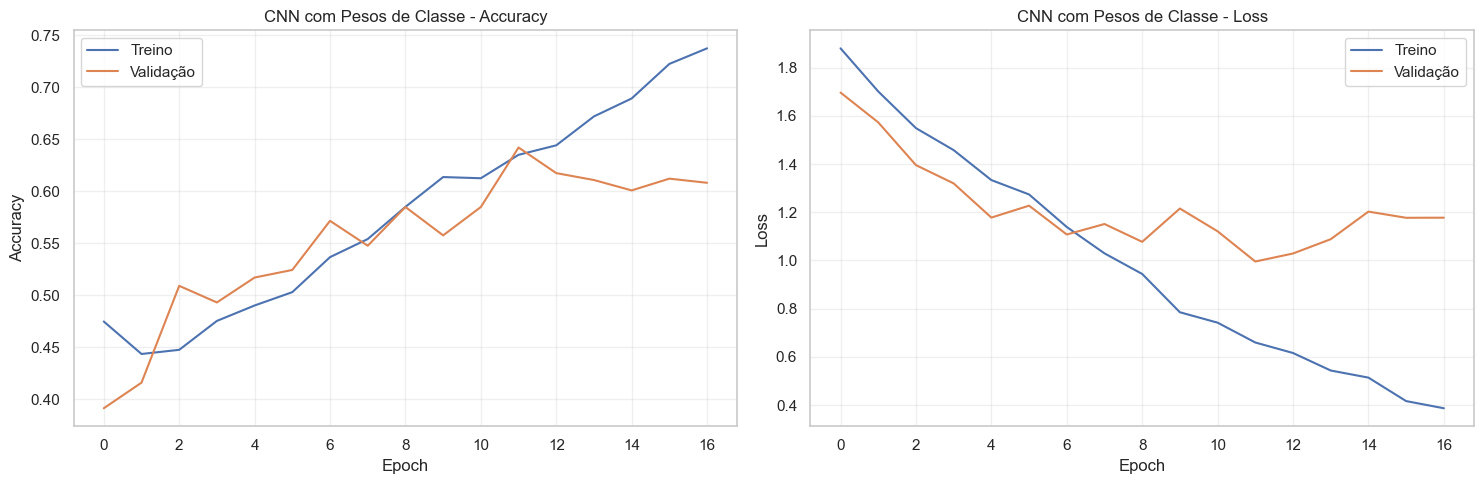

In [90]:
# 4. Curvas de treino/validação
plot_history(history_cnn_weights, model_name="CNN com Pesos de Classe")

O uso de pesos de classe altera significativamente o comportamento do treinamento. Observa-se que o modelo passa a dar mais importância às classes minoritárias, o que muda a dinâmica das curvas em relação à CNN simples.

Alguns pontos principais:

- A acurácia de treino cresce de forma consistente até cerca de 74%, mas de maneira mais lenta que antes. Isso é esperado, já que o modelo agora sofre penalizações maiores quando erra classes raras.

- A acurácia de validação também melhora até aproximadamente 64%, porém estabiliza logo depois, oscilando levemente.

- O loss de treino apresenta queda progressiva, semelhante ao modelo simples, mas começa em valores mais altos devido ao reponderamento das classes.

- O loss de validação cai até a metade do treinamento, mas passa a oscilar sem clara melhora adicional.

De modo geral, o modelo aprende, mas a discrepância entre treino e validação persiste. Contudo, o comportamento das curvas indica que o modelo foi forçado a se ajustar a classes antes negligenciadas, o que é refletido nos resultados por classe.

In [91]:
model_class_weights = load_model("models/cnn/class_weights.keras")
print("CNN com Pesos de Classe carregada!")

CNN com Pesos de Classe carregada!


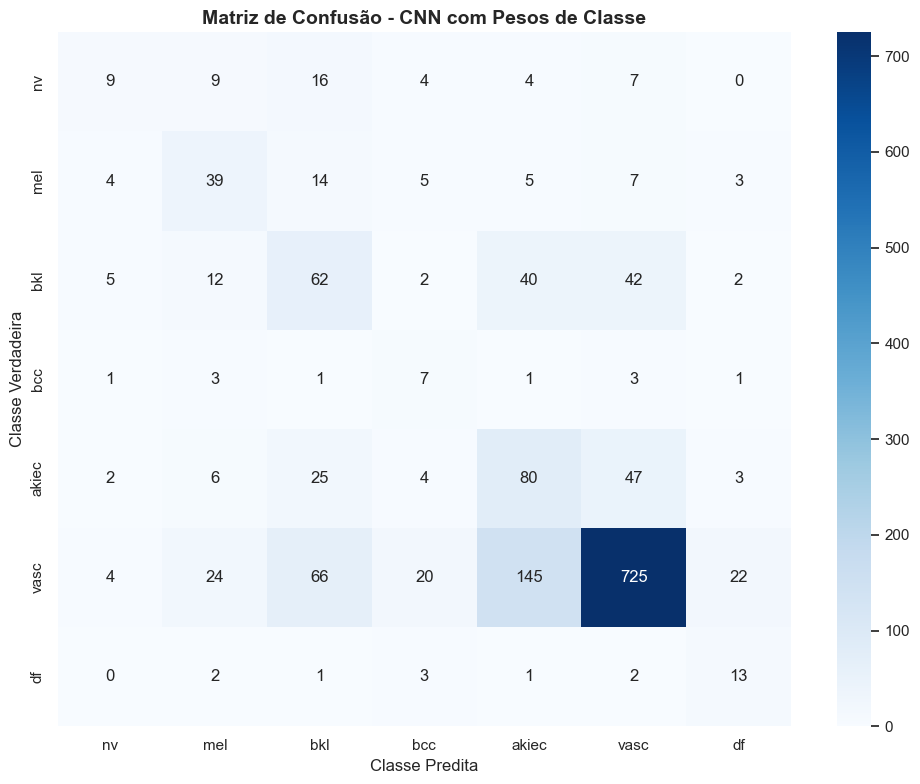

RELATÓRIO DE CLASSIFICAÇÃO - CNN COM PESOS DE CLASSE:
                       precision    recall  f1-score   support

  Nevos melanocíticos     0.3600    0.1837    0.2432        49
             Melanoma     0.4105    0.5065    0.4535        77
    Queratose benigna     0.3351    0.3758    0.3543       165
Carcinoma basocelular     0.1556    0.4118    0.2258        17
   Queratose actínica     0.2899    0.4790    0.3612       167
    Lesões vasculares     0.8703    0.7207    0.7885      1006
       Dermatofibroma     0.2955    0.5909    0.3939        22

             accuracy                         0.6221      1503
            macro avg     0.3881    0.4669    0.4029      1503
         weighted avg     0.6904    0.6221    0.6463      1503



In [93]:
# 5. Avaliação em teste: matriz de confusão + relatório

y_pred_cnn_weights = model_class_weights.predict(X_test, verbose=0)
y_pred_classes_cnn_weights = np.argmax(y_pred_cnn_weights, axis=1)

plot_confusion_and_report(
    y_true=y_test,
    y_pred=y_pred_classes_cnn_weights,
    class_names=class_names,
    model_name="CNN com Pesos de Classe",
)

1. **Métricas globais**

- Acurácia geral: **62,21%**, abaixo tanto da CNN simples (72,39%) quanto também abaixo do Dummy Classifier (66,93%).
- Macro avg:

  - recall ≈ 0,47
  - F1 ≈ 0,40
  - Esses valores são superiores aos da CNN simples em recall macro, indicando que o modelo passou a encontrar mais instâncias das classes minoritárias.

- Weighted avg:

  - recall ≈ 0,62
  - F1 ≈ 0,64
  - Redução em comparação ao modelo simples, consequência direta de menor acerto na classe majoritária.

Em resumo: globalmente o desempenho diminui, mas a distribuição dos acertos entre as classes torna-se mais equilibrada. O objetivo de melhorar sensibilidade das classes menores foi parcialmente atingido.

2. **Métricas por classe**

| Classe                | support | precision | recall | f1-score | Comentário                                                                 |
| --------------------- | ------- | --------- | ------ | -------- | -------------------------------------------------------------------------- |
| Nevos melanocíticos   | 49      | 0.36      | 0.18   | 0.24     | Leve melhora em comparação ao dummy, mas ainda baixo.                      |
| Melanoma              | 77      | 0.41      | 0.50   | 0.45     | Recall superior ao modelo simples; sensibilidade aumentou.                 |
| Queratose benigna     | 165     | 0.33      | 0.38   | 0.35     | Comportamento semelhante ao modelo anterior.                               |
| Carcinoma basocelular | 17      | 0.16      | 0.41   | 0.23     | Grande avanço: saiu de recall 0% para 41,18%.                              |
| Queratose actínica    | 167     | 0.29      | 0.48   | 0.36     | Outro caso em que o recall aumentou substancialmente.                      |
| Lesões vasculares     | 1006    | 0.87      | 0.72   | 0.79     | Caiu em recall (antes >90%), como esperado ao reduzir o peso dessa classe. |
| Dermatofibroma        | 22      | 0.30      | 0.59   | 0.39     | Recall aumentou muito; a rede agora identifica mais casos verdadeiros.     |

Estas métricas confirmam que o uso de pesos de classe reequilibrou a performance: classes antes ignoradas pelo modelo simples agora apresentam recall significativamente maior. A contrapartida é a piora na classe majoritária e, como consequência, queda na acurácia global.

3. **Conclusão**

A CNN com pesos de classe apresenta uma troca clara: perde desempenho global, mas melhora substancialmente nas classes minoritárias e de maior relevância clínica. Classes como carcinoma basocelular, dermatofibroma e queratose actínica passam a ser detectadas com recall entre 40% e 60%, contra valores próximos de zero no modelo sem pesos.

Apesar da acurácia total ter caído, o modelo apresenta distribuição mais justa entre as classes, atendendo melhor ao objetivo de combater o desbalanceamento. Ainda assim, não resolve o problema de generalização, sendo necessário buscar outras alternativas. 


---

### 5. CNN + Oversampling

Na CNN com pesos de classe nós diminuímos o viés para a classe majoritária ajustando a **função de perda**. Agora vamos testar uma abordagem complementar: **oversampling** das classes minoritárias.

A ideia é “aumentar” artificialmente as classes com poucos exemplos, replicando amostras (com reposição) até que todas as classes tenham aproximadamente o mesmo número de imagens. Assim, o modelo vê um conjunto de treino "balanceado", sem precisar alterar a loss via `class_weight`.

---

#### O que é oversampling e por que usar?


O **oversampling** é uma técnica de balanceamento em que:

- identificamos as classes com **menos exemplos**;
- **duplicamos** (ou sintetizamos) amostras dessas classes até que elas tenham um número de exemplos parecido com a classe majoritária.

No nosso caso:

- o dataset HAM10000 é fortemente desbalanceado (lesões vasculares dominam);
- sem tratamento, a CNN tende a focar quase só na classe majoritária;
- com oversampling, fazemos o modelo ver **tantos exemplos de classes raras** quanto de classes comuns, o que pode melhorar o **recall em classes minoritárias**.

Diferentemente dos *class weights*, o oversampling atua **nos dados**: ele cria um novo conjunto de treino balanceado. A função de loss permanece a mesma, mas o gradiente passa a ser influenciado por um número mais justo de exemplos de cada classe.

In [94]:
def oversample_by_class(X, y, random_state=SEED):
    """
    Faz oversampling simples replicando exemplos das classes minoritárias
    até igualar o número de amostras da classe majoritária.

    X: array de imagens, shape (N, H, W, C)
    y: array de rótulos inteiros, shape (N,)

    Retorna:
    X_over, y_over: conjunto de treino balanceado e embaralhado.
    """
    rng = np.random.RandomState(random_state)

    classes, counts = np.unique(y, return_counts=True)
    max_count = counts.max()

    X_resampled_list = []
    y_resampled_list = []

    for cls, count in zip(classes, counts):
        idx = np.where(y == cls)[0]
        X_cls = X[idx]
        y_cls = y[idx]

        # quantas amostras precisamos adicionar para chegar em max_count
        n_to_add = max_count - count

        if n_to_add > 0:
            extra_idx = rng.choice(idx, size=n_to_add, replace=True)
            X_extra = X[extra_idx]
            y_extra = y[extra_idx]

            X_cls = np.concatenate([X_cls, X_extra], axis=0)
            y_cls = np.concatenate([y_cls, y_extra], axis=0)

        X_resampled_list.append(X_cls)
        y_resampled_list.append(y_cls)

    # junta tudo e embaralha
    X_over = np.concatenate(X_resampled_list, axis=0)
    y_over = np.concatenate(y_resampled_list, axis=0)

    perm = rng.permutation(len(y_over))
    X_over = X_over[perm]
    y_over = y_over[perm]

    return X_over, y_over

In [95]:
print("Distribuição original (y_train):")

for idx, (code, name) in enumerate(class_names.items()):
    # conta quantas vezes o código aparece no vetor de treino
    count = np.sum(y_train == idx)
    print(f"  {idx}: {code:6s} -> {name:30s} ({count:4d} imagens)")

Distribuição original (y_train):
  0: nv     -> Nevos melanocíticos            ( 229 imagens)
  1: mel    -> Melanoma                       ( 360 imagens)
  2: bkl    -> Queratose benigna              ( 769 imagens)
  3: bcc    -> Carcinoma basocelular          (  80 imagens)
  4: akiec  -> Queratose actínica             ( 779 imagens)
  5: vasc   -> Lesões vasculares              (4693 imagens)
  6: df     -> Dermatofibroma                 (  99 imagens)


In [96]:

X_train_over, y_train_over = oversample_by_class(X_train, y_train, random_state=SEED)

# Recria os rótulos one-hot para o novo conjunto de treino
y_train_over_encoded = to_categorical(y_train_over, num_classes=num_classes)

In [97]:
print("Distribuição após oversampling:")
for idx, (code, name) in enumerate(class_names.items()):
    count = np.sum(y_train_over == idx)
    print(f"  {idx}: {code:6s} -> {name:30s} ({count:4d} imagens)")

Distribuição após oversampling:
  0: nv     -> Nevos melanocíticos            (4693 imagens)
  1: mel    -> Melanoma                       (4693 imagens)
  2: bkl    -> Queratose benigna              (4693 imagens)
  3: bcc    -> Carcinoma basocelular          (4693 imagens)
  4: akiec  -> Queratose actínica             (4693 imagens)
  5: vasc   -> Lesões vasculares              (4693 imagens)
  6: df     -> Dermatofibroma                 (4693 imagens)


Como esperado, após o oversampling, todas as classes passam a ter omesmo número de exemplos no conjunto de treino. Isso força a CNN a “enxergar” com mais frequência as classes minoritárias durante o treino.


### Implementação

In [100]:
# 1. Construção do modelo
input_shape = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)
model_cnn_over = build_simple_cnn(input_shape, num_classes)

model_cnn_over.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,455,207 (32.25 MB)

 Trainable params: 8,455,207 (32.25 MB)

 Non-trainable params: 0 (0.00 B)

In [101]:

# 2. Compilação (podemos usar a mesma LR reduzida que funcionou bem)
optimizer = Adam(learning_rate=0.0005)

model_cnn_over.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

# Earliness stopping
early_stopping_over = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
)


# 3. Callback para reduzir LR se a validação estagnar
learning_rate_reduction_over = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    verbose=1,
    factor=0.5,
    min_lr=1e-6,
)

print("CNN com Oversampling compilada!")

CNN com Oversampling compilada!


Agora treinamos a CNN usando o novo conjunto de treino balanceado `X_train_over` / `y_train_over_encoded`. A validação continua sendo feita no conjunto original de validação (`X_val`, `y_val_encoded`), que mantém a distribuição real do problema.

In [102]:
history_cnn_over = model_cnn_over.fit(
    X_train_over, y_train_over_encoded,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val_encoded),
    callbacks=[learning_rate_reduction_over, early_stopping_over],
    verbose=1,
)


Epoch 1/30
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 142s 137ms/step - accuracy: 0.5509 - loss: 1.1613 - val_accuracy: 0.5702 - val_loss: 1.1186 - learning_rate: 5.0000e-04
Epoch 2/30
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 142s 138ms/step - accuracy: 0.7909 - loss: 0.5346 - val_accuracy: 0.6028 - val_loss: 1.0503 - learning_rate: 5.0000e-04
Epoch 3/30
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 145s 142ms/step - accuracy: 0.8557 - loss: 0.3653 - val_accuracy: 0.6547 - val_loss: 1.1028 - learning_rate: 5.0000e-04
Epoch 4/30
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 145s 142ms/step - accuracy: 0.8835 - loss: 0.2918 - val_accuracy: 0.6587 - val_loss: 1.2293 - learning_rate: 5.0000e-04
Epoch 5/30
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.8981 - loss: 0.2588
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 145s 142ms/step - accuracy: 0.9023 - loss: 0.2497 - val_accuracy: 0.6986 - val_loss: 1.3238 - learning_rate: 5.0000e-04
Epoch 6/30
1027/1027 ━━━━━━━━━━━━━━

In [103]:
model_cnn_over.save("models/cnn/oversampling.keras")
print("Modelo salvo em models/cnn/oversampling.keras")

Modelo salvo em models/cnn/oversampling.keras


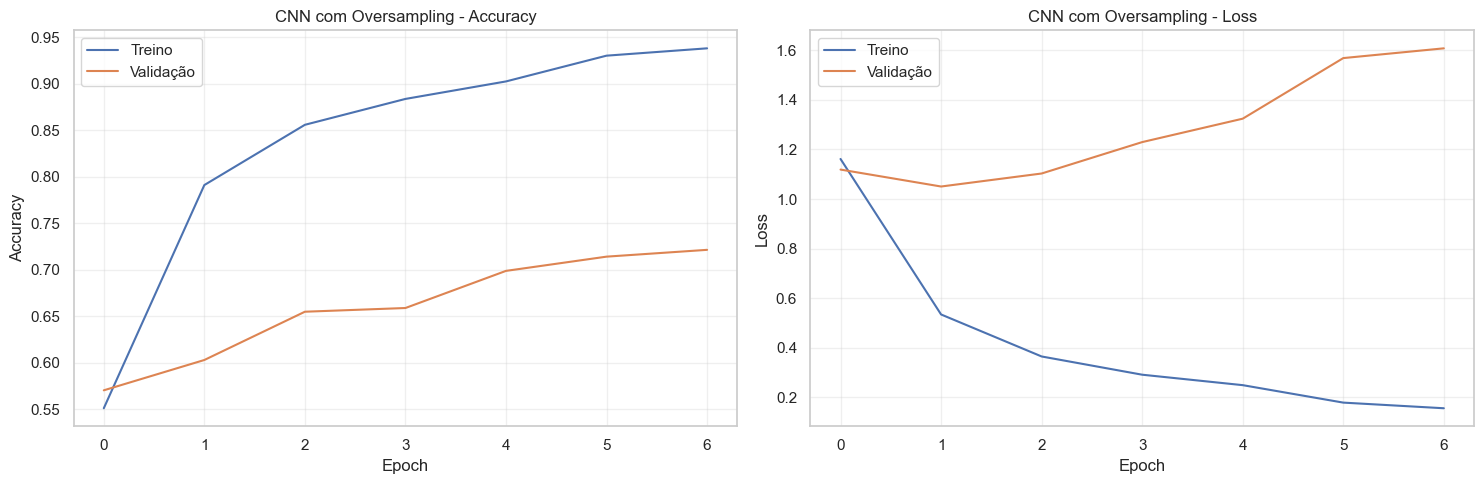

In [104]:
plot_history(history_cnn_over, model_name="CNN com Oversampling")

O oversampling altera substancialmente o comportamento do treinamento. Como as classes minoritárias passam a aparecer com maior frequência no conjunto de treino, a rede aprende mais rapidamente, porém, as curvas revelam problemas sérios de generalização.

Observações principais:

- A acurácia de treino cresce de forma extremamente rápida, atingindo cerca de 94% já na 6ª época.

- A acurácia de validação sobe no início, mas estabiliza cedo em torno de 72%, sem acompanhar o ritmo do treino.

- O loss de treino cai de maneira agressiva, indicando forte memorização.

- O loss de validação aumenta continuamente após a 1ª época, chegando a valores acima de 1.5.

O padrão é característico de overfitting. O oversampling, ao replicar imagens das classes raras, tende a reforçar padrões específicos dessas cópias, dificultando a generalização e provocando divergência entre treino e validação. O modelo aprende a memorizar instâncias duplicadas em vez de aprender características generalizáveis.

In [108]:
# Carregar modelo salvo
model_oversampling = load_model("models/cnn/oversampling.keras")
print("CNN com Oversampling carregada!")

CNN com Oversampling carregada!


In [109]:
# Predições em validação e teste
y_val_pred_over_probs = model_cnn_over.predict(X_val, verbose=0)
y_test_pred_over_probs = model_cnn_over.predict(X_test, verbose=0)

y_val_pred_over = np.argmax(y_val_pred_over_probs, axis=1)
y_test_pred_over = np.argmax(y_test_pred_over_probs, axis=1)

CNN com Oversampling:
Acurácia Validação: 60.28%
Acurácia Teste:     61.28%


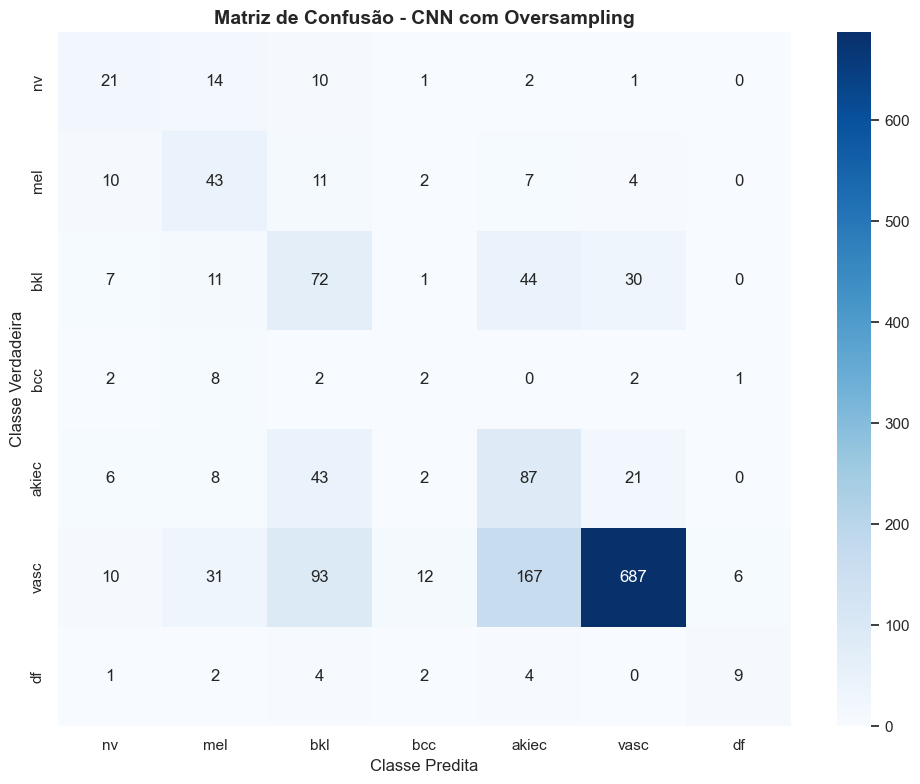

RELATÓRIO DE CLASSIFICAÇÃO - CNN COM OVERSAMPLING:
                       precision    recall  f1-score   support

  Nevos melanocíticos     0.3684    0.4286    0.3962        49
             Melanoma     0.3675    0.5584    0.4433        77
    Queratose benigna     0.3064    0.4364    0.3600       165
Carcinoma basocelular     0.0909    0.1176    0.1026        17
   Queratose actínica     0.2797    0.5210    0.3640       167
    Lesões vasculares     0.9221    0.6829    0.7847      1006
       Dermatofibroma     0.5625    0.4091    0.4737        22

             accuracy                         0.6128      1503
            macro avg     0.4139    0.4506    0.4178      1503
         weighted avg     0.7220    0.6128    0.6489      1503



In [110]:
print_accuracy_summary(
    model_name="CNN com Oversampling",
    y_val_true=y_val,
    y_val_pred=y_val_pred_over,
    y_test_true=y_test,
    y_test_pred=y_test_pred_over,
)

# Matriz de confusão + classification_report
plot_confusion_and_report(
    y_true=y_test,
    y_pred=y_test_pred_over,
    class_names=class_names,
    model_name="CNN com Oversampling",
)

1. Métricas globais

- Acurácia geral: **61,28%**, próximo ao modelo com pesos de classe (62,21%), mas inferior tanto à CNN simples (72,39%) quanto ao Dummy Classifier (66,93%).
- Macro avg:

  - recall ≈ 0,45
  - F1 ≈ 0,41
  - Valores semelhantes aos obtidos com pesos de classe, indicando maior equilíbrio entre classes.
- Weighted avg:

  - recall ≈ 0,61
  - F1 ≈ 0,65
    Levemente inferior ao modelo com pesos de classe, porém superior ao dummy em termos ponderados.

Em síntese: apesar da queda na acurácia geral, o oversampling melhora a sensibilidade de algumas classes sub-representadas, mas falha em estabilizar o desempenho e mantém forte dificuldade de generalização.

2. Métricas por classe

| Classe                | support | precision | recall | f1-score | Comentário                                                               |
| --------------------- | ------- | --------- | ------ | -------- | ------------------------------------------------------------------------ |
| Nevos melanocíticos   | 49      | 0.36      | 0.43   | 0.40     | Sensívelmente melhor que com pesos; recall mais alto.                    |
| Melanoma              | 77      | 0.37      | 0.56   | 0.44     | Recall elevado, superando tanto a CNN simples quanto o modelo com pesos. |
| Queratose benigna     | 165     | 0.30      | 0.44   | 0.36     | Melhor recall, precisão baixa; resultado mediano.                        |
| Carcinoma basocelular | 17      | 0.09      | 0.12   | 0.10     | Desempenho fraco; oversampling não resolveu esta classe.                 |
| Queratose actínica    | 167     | 0.28      | 0.52   | 0.36     | Aumento significativo no recall; um dos melhores ganhos do oversampling. |
| Lesões vasculares     | 1006    | 0.92      | 0.68   | 0.78     | Recall reduzido em relação à CNN simples, como era esperado.             |
| Dermatofibroma        | 22      | 0.56      | 0.41   | 0.47     | Desempenho razoável, F1 maior que no modelo com pesos.                   |

Esses resultados confirmam que o oversampling aumentou a capacidade da rede de identificar classes minoritárias, especialmente melanoma e queratose actínica, mas isso veio ao custo de piora na classe majoritária e queda geral na acurácia.

3. Conclusão

A CNN com oversampling apresenta desempenho similar ao modelo com pesos de classe em termos de recall macro, mas não supera nenhuma abordagem em acurácia geral. O oversampling melhora a detecção das classes minoritárias, indicando que a estratégia contribui para reduzir o viés do modelo, mas ao replicar imagens gera forte overfitting e instabilidade no conjunto de validação.

Em comparação com o modelo com pesos de classe, o oversampling mostra alguns ganhos específicos (como recall mais alto em melanoma e queratose actínica), mas perde em estabilidade e qualidade global do modelo. As curvas reforçam que o oversampling simples não é suficiente para lidar com o desbalanceamento sem prejudicar a generalização.


---

### 6. CNN com Oversampling + Data Augmentation

Nesta variação foi utilizada duas estratégias para lidar com o desbalanceamento e a escassez de dados em algumas classes:

1. **Oversampling**  

2. **Data Augmentation**  
   - Aplica transformações aleatórias nas imagens (rotações, zoom, flips, translações, etc.) a cada época.
   - Aumenta a diversidade das amostras sem coletar novas imagens, ajudando a reduzir overfitting e tornando o modelo mais robusto.

Ao combinar **oversampling + data augmentation**, nós:

- equilibramos a **quantidade** de exemplos por classe (oversampling); e  
- aumentamos a **variedade** de exemplos dentro de cada classe (augmentation).

O oversampling é aplicado **somente no conjunto de treino**, enquanto a validação e o teste continuam usando os dados originais, preservando a distribuição real do problema.

---

#### Aplicando Data Augmentation nos valores de Oversampling

In [119]:
train_datagen_over = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Gerador para o treino oversampled + augmentado
train_generator_over = train_datagen_over.flow(
    X_train_over,
    y_train_over_encoded,
    batch_size=BATCH_SIZE,
    shuffle=True
)

---

#### Implementação

Usamos a mesma arquitetura convolucional das outras CNNs. A diferença central está no pipeline de dados: agora o modelo é treinado em um conjunto balanceado via oversampling e enriquecido com data augmentation.

In [120]:
# 1. Construção do modelo
input_shape = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)

model_cnn_over_aug = build_simple_cnn(input_shape, num_classes)

model_cnn_over_aug.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,455,207 (32.25 MB)

 Trainable params: 8,455,207 (32.25 MB)

 Non-trainable params: 0 (0.00 B)

In [121]:
# 2. Compilação
optimizer = Adam(learning_rate=0.0005)

model_cnn_over_aug.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

# Earliness stopping
early_stopping_over_aug = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
)

learning_rate_reduction_over_aug = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    verbose=1,
    factor=0.5,
    min_lr=1e-6,
)

print("CNN com Oversampling + Data Augmentation compilada!")

CNN com Oversampling + Data Augmentation compilada!


In [122]:
EPOCHS = 30 

steps_per_epoch = train_generator_over.n // train_generator_over.batch_size


history_cnn_over_aug = model_cnn_over_aug.fit(
    train_generator_over,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=(X_val, y_val_encoded),
    callbacks=[learning_rate_reduction_over_aug, early_stopping_over_aug],
    verbose=1,
)

Epoch 1/30
1026/1026 ━━━━━━━━━━━━━━━━━━━━ 157s 151ms/step - accuracy: 0.4543 - loss: 1.3956 - val_accuracy: 0.5729 - val_loss: 1.0293 - learning_rate: 5.0000e-04
Epoch 2/30
1026/1026 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5312 - loss: 1.1332 - val_accuracy: 0.5682 - val_loss: 1.0454 - learning_rate: 5.0000e-04
Epoch 3/30
1026/1026 ━━━━━━━━━━━━━━━━━━━━ 154s 150ms/step - accuracy: 0.5815 - loss: 1.0851 - val_accuracy: 0.5602 - val_loss: 1.0423 - learning_rate: 5.0000e-04
Epoch 4/30
1026/1026 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6250 - loss: 0.9952 - val_accuracy: 0.5642 - val_loss: 1.0257 - learning_rate: 5.0000e-04
Epoch 5/30
1026/1026 ━━━━━━━━━━━━━━━━━━━━ 158s 154ms/step - accuracy: 0.6361 - loss: 0.9457 - val_accuracy: 0.5855 - val_loss: 1.0167 - learning_rate: 5.0000e-04
Epoch 6/30
1026/1026 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6875 - loss: 0.7031 - val_accuracy: 0.5749 - val_loss: 1.0187 - learning_rate: 5.0000e-04
Epoch 7/30
1026/1026 ━━━━━━━━━━━━━━━━━━━

In [123]:
# Salvar modelo
model_cnn_over_aug.save("models/cnn/augmentada.keras")
print("CNN com Oversampling + Data Augmentation salva!")

CNN com Oversampling + Data Augmentation salva!


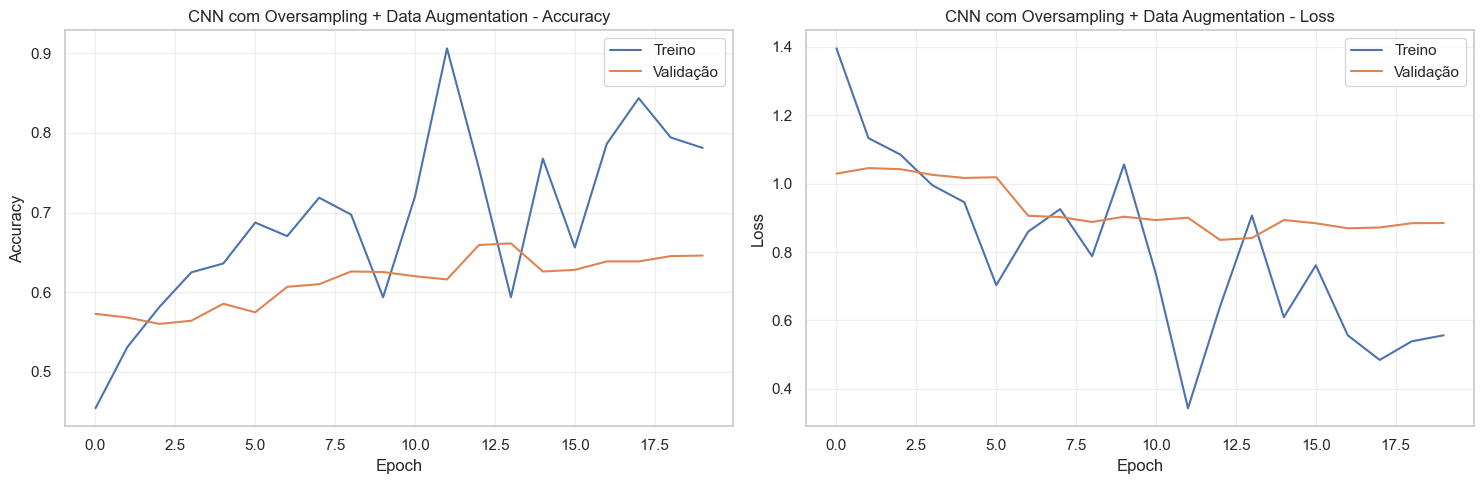

In [124]:
# Curvas de treino / validação
plot_history(history_cnn_over_aug, model_name="CNN com Oversampling + Data Augmentation")

A introdução de data augmentation variável por época altera significativamente o comportamento do modelo. Diferente do oversampling simples, onde a rede facilmente memoriza as instâncias duplicadas, aqui as transformações constantes impedem essa memorização direta.

Principais observações:

- A acurácia de treino se mantém alta, porém muito instável, oscilando entre cerca de 60% e 90%. Essa variabilidade é esperada quando há forte data augmentation, pois cada época apresenta versões diferentes das imagens.

- A acurácia de validação cresce até aproximadamente 65%, com comportamento mais estável que o treino. Não acompanha os picos do treinamento, o que evidencia que o modelo está sendo forçado a generalizar.

- O loss de treino apresenta quedas acentuadas seguidas de picos, refletindo a instabilidade gerada pelas transformações constantes.

- O loss de validação permanece relativamente estável entre 0.85 e 0.95, sem aumento explosivo como no oversampling simples.

O padrão indica que o data augmentation cumpre seu papel de reduzir overfitting: mesmo com oversampling, o modelo não memoriza cópias estáticas das imagens. Ainda assim, a convergência é mais lenta e ruidosa devido à alta variação no conjunto de treino.

In [125]:
# Carregar modelo salvo
model_cnn_over_aug = load_model("models/cnn/augmentada.keras")
print("CNN com Oversampling + Data Augmentation carregada!")

CNN com Oversampling + Data Augmentation carregada!


CNN com Oversampling + Data Augmentation:
Acurácia Validação: 65.93%
Acurácia Teste:     63.41%


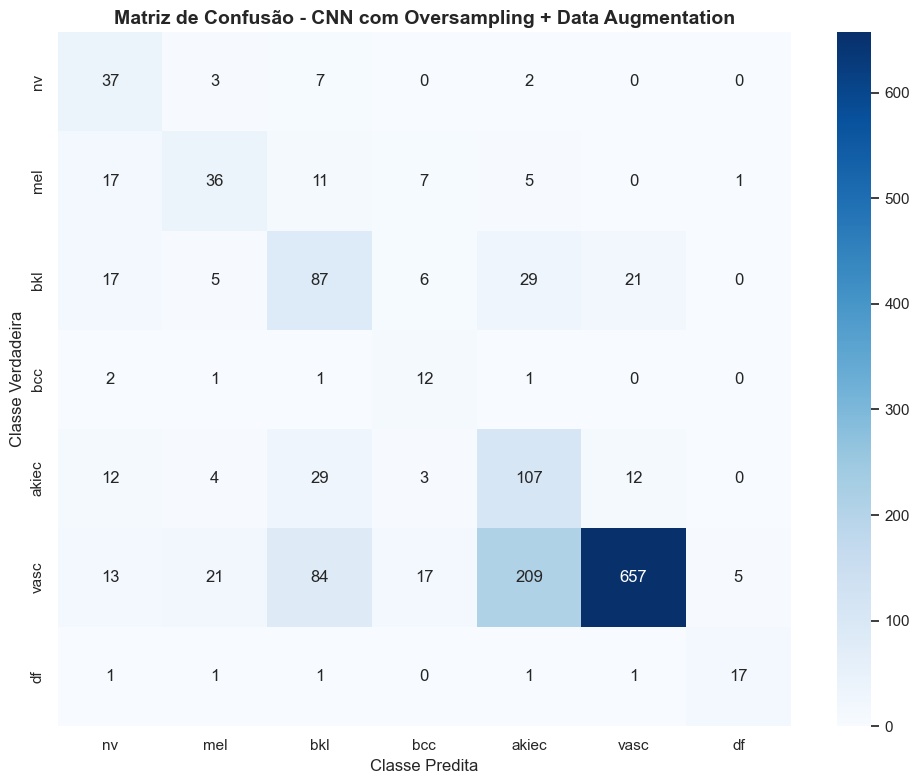

RELATÓRIO DE CLASSIFICAÇÃO - CNN COM OVERSAMPLING + DATA AUGMENTATION:
                       precision    recall  f1-score   support

  Nevos melanocíticos     0.3737    0.7551    0.5000        49
             Melanoma     0.5070    0.4675    0.4865        77
    Queratose benigna     0.3955    0.5273    0.4519       165
Carcinoma basocelular     0.2667    0.7059    0.3871        17
   Queratose actínica     0.3023    0.6407    0.4107       167
    Lesões vasculares     0.9508    0.6531    0.7743      1006
       Dermatofibroma     0.7391    0.7727    0.7556        22

             accuracy                         0.6341      1503
            macro avg     0.5050    0.6460    0.5380      1503
         weighted avg     0.7654    0.6341    0.6702      1503



In [126]:
# Predições
y_val_pred_over_aug_probs = model_cnn_over_aug.predict(X_val, verbose=0)
y_test_pred_over_aug_probs = model_cnn_over_aug.predict(X_test, verbose=0)

y_val_pred_over_aug = np.argmax(y_val_pred_over_aug_probs, axis=1)
y_test_pred_over_aug = np.argmax(y_test_pred_over_aug_probs, axis=1)

# Resumo de acurácia
print_accuracy_summary(
    model_name="CNN com Oversampling + Data Augmentation",
    y_val_true=y_val,
    y_val_pred=y_val_pred_over_aug,
    y_test_true=y_test,
    y_test_pred=y_test_pred_over_aug,
)

# Matriz de confusão + classification_report
plot_confusion_and_report(
    y_true=y_test,
    y_pred=y_test_pred_over_aug,
    class_names=class_names,
    model_name="CNN com Oversampling + Data Augmentation",
)

1. Métricas globais

- Acurácia geral: **63,41%**, ligeiramente superior ao oversampling simples (61,28%) e similar ao modelo com pesos (62,21%). Ainda abaixo do Dummy Classifier (66,93%).
- Macro avg:

  - recall ≈ 0,64
  - F1 ≈ 0,54
  - Valores significativamente superiores aos obtidos por qualquer uma das abordagens anteriores. Esse é o ponto mais relevante: melhora substancial para todas as classes ao mesmo tempo.
- Weighted avg:

  - recall ≈ 0,63
  - F1 ≈ 0,67
  - Retorno mais equilibrado, sem depender apenas da classe majoritária.

Em resumo: apesar de a acurácia global não ser alta, a distribuição do desempenho entre todas as classes é a melhor observada até o momento.

2. Métricas por classe

| Classe                | support | precision | recall | f1-score | Comentário                                                                 |
| --------------------- | ------- | --------- | ------ | -------- | -------------------------------------------------------------------------- |
| Nevos melanocíticos   | 49      | 0.37      | 0.76   | 0.50     | Grande avanço em recall; mais da metade dos casos agora são identificados. |
| Melanoma              | 77      | 0.51      | 0.47   | 0.49     | Desempenho Médio.                                        |
| Queratose benigna     | 165     | 0.40      | 0.53   | 0.45     | Sensível melhora em recall; desempenho superior ao oversampling simples.   |
| Carcinoma basocelular | 17      | 0.27      | 0.71   | 0.39     | Um dos maiores ganhos: recall muito superior às abordagens anteriores.     |
| Queratose actínica    | 167     | 0.30      | 0.64   | 0.41     | Notável aumento em recall; antes variava entre 18% e 52%.                  |
| Lesões vasculares     | 1006    | 0.95      | 0.65   | 0.77     | A classe majoritária perdeu recall, mas mantém boa precisão e F1.          |
| Dermatofibroma        | 22      | 0.74      | 0.77   | 0.76     | Melhor desempenho até aqui; excelente recall e F1 elevados.                |

Os resultados deixam claro que o modelo está muito mais equilibrado. A maioria das classes apresenta recall acima de 50%, caso inédito até este ponto das experimentações. As classes mais difíceis (carcinoma basocelular e queratose actínica) demonstram avanços expressivos.

3. Conclusão

O uso de oversampling combinado com data augmentation variável em cada época se mostrou o método mais eficaz até o momento para lidar com o desbalanceamento. Embora a acurácia global permaneça inferior ao baseline dummy, o desempenho por classe, especialmente recall macro, melhora substancialmente.

Diferente do oversampling simples, que gerava overfitting severo, a variação contínua das imagens impede a memorização e força a rede a aprender padrões mais gerais. Isso se reflete em ganhos marcantes em classes minoritárias.

Entre todas as abordagens testadas até agora, esta é a que apresenta o melhor equilíbrio entre as classes e os maiores avanços em recall macro.


---

### 7. CNN + Metadata

Até aqui, todos os modelos usaram apenas as **imagens de pele** como entrada. Porém, o dataset HAM10000 também traz informações tabulares (metadados), como:

- idade do paciente,
- sexo,
- localização anatômica da lesão,

Essas variáveis carregam contexto clínico importante: por exemplo, alguns tipos de lesão são mais comuns em certas faixas etárias ou regiões do corpo.

Nesta seção, construímos uma **rede multimodal**, que recebe:

1. uma imagem (processada por uma CNN)  
2. um vetor de metadados (processado por camadas densas)

O modelo combina essas duas fontes de informação para fazer a classificação final. A ideia é que os metadados ajudem a reduzir ambiguidades entre lesões que
são visualmente parecidas, mas clinicamente diferentes.

---

#### Implementação

A arquitetura de imagem reutiliza a mesma CNN simples usada nas seçõesanteriores. Em paralelo, um pequeno MLP processa o vetor de metadados. As duas representações são concatenadas e passam por camadas densas adicionais, resultando na camada `softmax` final.

In [127]:
# 1. Construção do modelo
input_shape = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)

model_cnn_meta = build_cnn_with_metadata(
    image_shape=input_shape,
    metadata_dim=num_meta_features,
    num_classes=num_classes
)

model_cnn_meta.summary()

Model: "cnn_with_metadata"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 128, 128,  │        896 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 128, 128,  │      9,248 │ conv2d_32[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 64, 64,    │          0 │ conv2d_33[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_48          │ (None, 64, 64,    │          0 │ max_pooling2d_16… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 64, 64,    │     18,496 │ dropout_48[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_input      │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_34[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 64)        │      1,280 │ metadata_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_17    │ (None, 32, 32,    │          0 │ conv2d_35[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_50          │ (None, 64)        │          0 │ dense_20[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_49          │ (None, 32, 32,    │          0 │ max_pooling2d_17… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 32)        │      2,080 │ dropout_50[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 65536)     │          0 │ dropout_49[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_51          │ (None, 32)        │          0 │ dense_21[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 65568)     │          0 │ flatten_8[0][0],  │
│ (Concatenate)       │                   │            │ dropout_51[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 128)       │  8,392,832 │ fusion_concat[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_52          │ (None, 128)       │          0 │ dense_22[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 8,462,663 (32.28 MB)

 Trainable params: 8,462,663 (32.28 MB)

 Non-trainable params: 0 (0.00 B)

In [128]:
# 2. Compilação
optimizer = Adam(learning_rate=0.0005)

model_cnn_meta.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

# Earliness stopping
early_stopping_meta = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
)


learning_rate_reduction_meta = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    verbose=1,
    factor=0.5,
    min_lr=1e-6,
)

print("CNN com Imagens + Metadados compilada!")

CNN com Imagens + Metadados compilada!


In [129]:
# 3. Treinamento
history_cnn_meta = model_cnn_meta.fit(
    [X_train, meta_train], 
    y_train_encoded,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=([X_val, meta_val], y_val_encoded),
    callbacks=[learning_rate_reduction_meta, early_stopping_meta],
    verbose=1,
)

Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 34s 150ms/step - accuracy: 0.6780 - loss: 0.9607 - val_accuracy: 0.6959 - val_loss: 0.8142 - learning_rate: 5.0000e-04
Epoch 2/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 32s 146ms/step - accuracy: 0.7138 - loss: 0.7951 - val_accuracy: 0.7379 - val_loss: 0.7051 - learning_rate: 5.0000e-04
Epoch 3/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 32s 146ms/step - accuracy: 0.7345 - loss: 0.7352 - val_accuracy: 0.7498 - val_loss: 0.6750 - learning_rate: 5.0000e-04
Epoch 4/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 32s 146ms/step - accuracy: 0.7490 - loss: 0.6851 - val_accuracy: 0.7545 - val_loss: 0.6528 - learning_rate: 5.0000e-04
Epoch 5/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 32s 147ms/step - accuracy: 0.7632 - loss: 0.6484 - val_accuracy: 0.7578 - val_loss: 0.6558 - learning_rate: 5.0000e-04
Epoch 6/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 32s 147ms/step - accuracy: 0.7763 - loss: 0.6211 - val_accuracy: 0.7591 - val_loss: 0.6663 - learning_rate: 5.0000e-04
Epoch 7/30
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 141

In [130]:
# Salvar modelo
model_cnn_meta.save("models/cnn/metadata.keras")
print("CNN com Imagens + Metadados salva!")

CNN com Imagens + Metadados salva!


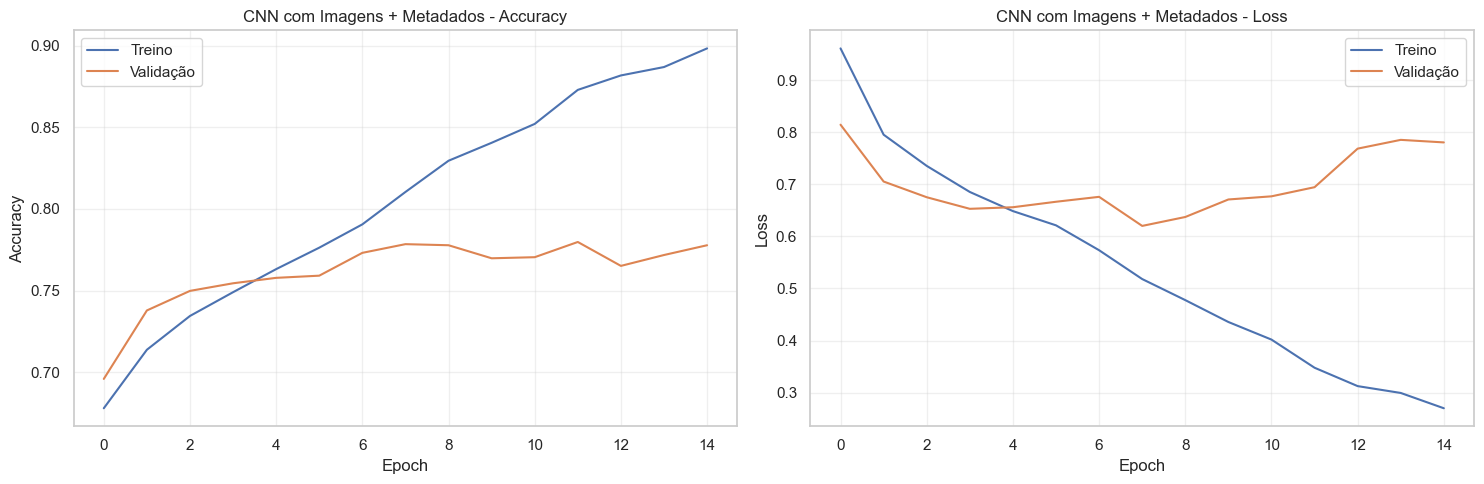

In [131]:
plot_history(history_cnn_meta, model_name="CNN com Imagens + Metadados")

A inclusão de metadados (idade, sexo e localização anatômica) altera o comportamento do treinamento e, de forma geral, melhora a capacidade preditiva do modelo. As curvas indicam um aprendizado mais estável do que nas abordagens com oversampling.

Observações principais:

- A acurácia de treino aumenta de maneira consistente, chegando próximo de 90% ao final.

- A acurácia de validação cresce até ~78%, estabilizando por volta desse valor — desempenho superior ao de todos os modelos anteriores.

- O loss de treino diminui de maneira contínua, sem oscilações bruscas.

- O loss de validação cai nas primeiras épocas e depois apresenta pequenas oscilações, mas sem o crescimento acentuado que caracterizava o oversampling simples.

In [132]:
# Carregar modelo salvo
model_cnn_metadata = load_model("models/cnn/metadata.keras")
print("CNN com Imagens + Metadados carregada!")

CNN com Imagens + Metadados carregada!


CNN com Imagens + Metadados:
Acurácia Validação: 77.84%
Acurácia Teste:     74.72%


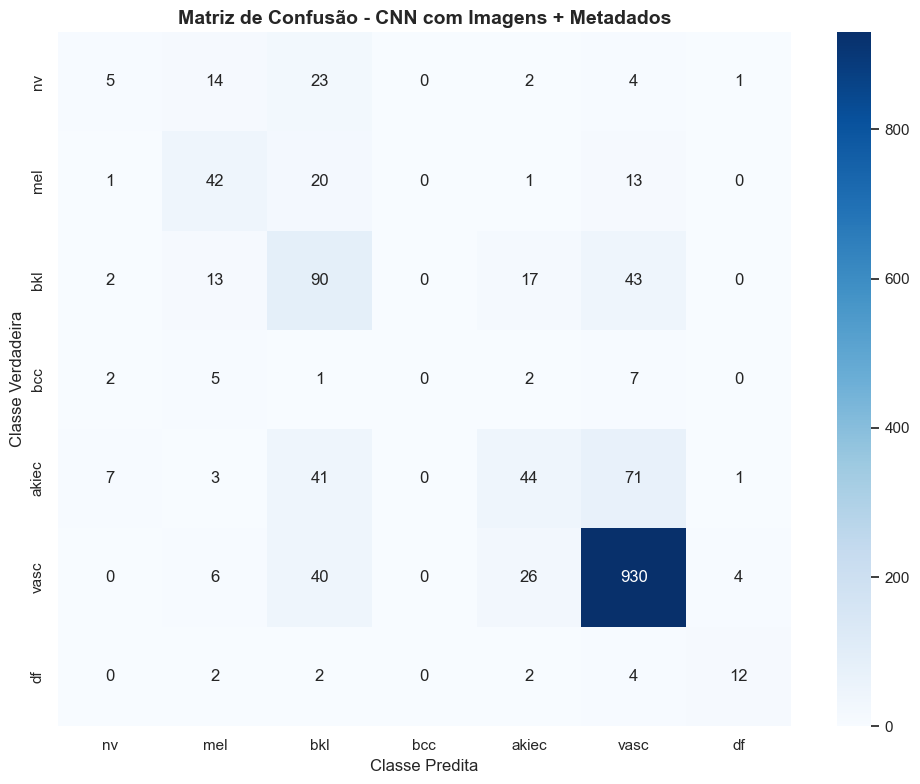

RELATÓRIO DE CLASSIFICAÇÃO - CNN COM IMAGENS + METADADOS:
                       precision    recall  f1-score   support

  Nevos melanocíticos     0.2941    0.1020    0.1515        49
             Melanoma     0.4941    0.5455    0.5185        77
    Queratose benigna     0.4147    0.5455    0.4712       165
Carcinoma basocelular     0.0000    0.0000    0.0000        17
   Queratose actínica     0.4681    0.2635    0.3372       167
    Lesões vasculares     0.8675    0.9245    0.8951      1006
       Dermatofibroma     0.6667    0.5455    0.6000        22

             accuracy                         0.7472      1503
            macro avg     0.4579    0.4180    0.4248      1503
         weighted avg     0.7229    0.7472    0.7286      1503



In [133]:
# Predições
y_val_pred_meta_probs = model_cnn_meta.predict([X_val, meta_val], verbose=0)
y_test_pred_meta_probs = model_cnn_meta.predict([X_test, meta_test], verbose=0)

y_val_pred_meta = np.argmax(y_val_pred_meta_probs, axis=1)
y_test_pred_meta = np.argmax(y_test_pred_meta_probs, axis=1)

# Resumo de acurácia
print_accuracy_summary(
    model_name="CNN com Imagens + Metadados",
    y_val_true=y_val,
    y_val_pred=y_val_pred_meta,
    y_test_true=y_test,
    y_test_pred=y_test_pred_meta,
)

# Matriz de confusão + classification_report
plot_confusion_and_report(
    y_true=y_test,
    y_pred=y_test_pred_meta,
    class_names=class_names,
    model_name="CNN com Imagens + Metadados",
)

1. Métricas globais

- Acurácia geral: **74,72%**, superior à CNN simples (72,39%), ao oversampling (61,28%), pesos de classe (62,21%) e oversampling + augmentation (63,41%).
- Macro avg:

  - recall ≈ 0,42
  - F1 ≈ 0,42
  - Valores moderados; ainda existe disparidade entre classes.
- Weighted avg:

  - recall ≈ 0,75
  - F1 ≈ 0,73
   - São valores elevados, indicando que o modelo funciona bem no conjunto como um todo, mas continua sofrendo com classes menos frequentes.

Conclusão parcial: os metadados ajudam a melhorar a acurácia global e fornecem informações complementares úteis ao modelo. Contudo, como o desbalanceamento não foi tratado, parte do viés estrutural permanece.

2. Métricas por classe

| Classe                | support | precision | recall | f1-score | Comentário                                                                                       |
| --------------------- | ------- | --------- | ------ | -------- | ------------------------------------------------------------------------------------------------ |
| Nevos melanocíticos   | 49      | 0.29      | 0.10   | 0.15     | Desempenho fraco; recall muito baixo. Informações adicionais não resolveram esta classe.         |
| Melanoma              | 77      | 0.49      | 0.55   | 0.52     | Detecta pouco mais da metade dos melanomas.                                   |
| Queratose benigna     | 165     | 0.41      | 0.55   | 0.47     | Classe moderada; melhora em recall em relação aos primeiros modelos.                             |
| Carcinoma basocelular | 17      | 0.00      | 0.00   | 0.00     | Não detecta nenhum caso, comportamento similar ao dummy.                                         |
| Queratose actínica    | 167     | 0.47      | 0.26   | 0.34     | Melhor que a CNN simples, mas inferior ao oversampling + augmentation.                           |
| Lesões vasculares     | 1006    | 0.87      | 0.92   | 0.89     | Classe dominante com desempenho excelente. Alta precisão e sensibilidade.                        |
| Dermatofibroma        | 22      | 0.67      | 0.55   | 0.60     | Ainda inferior ao oversampling + augmentation (que atingiu recall maior). |

Os metadados melhoraram o comportamento global, mas não corrigiram classes problemáticas. Especialmente carcinoma basocelular e nevos melanocíticos continuam com recall muito baixo, demonstrando que o modelo, mesmo enriquecido com informação tabular, ainda sofre com o desbalanceamento.

3. Conclusão

A CNN com imagens + metadados apresenta a **melhor acurácia global** entre todos os modelos testados até agora. Isso confirma que idade, sexo e localização anatômica oferecem informação discriminante relevante ao classificador.

Porém, como nenhuma técnica contra desbalanceamento foi utilizada, o viés estrutural do dataset permanece evidente: classes minoritárias continuam com desempenho baixo ou nulo. As classes majoritárias, especialmente lesões vasculares, continuam guiando o desempenho global do modelo.

### 8. CNN utilizando Metadata + Oversampling + Data Augmentation

Por fim, combinamos todas as estratégias anteriores em um único modelo:

- **Imagens**: processadas pela CNN principal;
- **Metadados clínicos**: (idade, sexo, localização);
- **Oversampling**: balanceia o conjunto de treino repetindo exemplos das classes minoritárias;
- **Data Augmentation**: aplica transformações aleatórias nas imagens (rotação, deslocamento, zoom) a cada época.

A ideia é usar:
- os **metadados** para fornecer contexto clínico adicional;
- o **oversampling** para reduzir o viés da classe majoritária;
- o **data augmentation** para melhorar a capacidade de generalização do modelo.

---

#### Alinhando Imagem e Metadata

In [134]:
# Índices como "feature" para recuperar imagens e metadados depois
indices = np.arange(len(y_train)).reshape(-1, 1)

ros = RandomOverSampler(random_state=SEED)
oversampled_idx, y_train_over = ros.fit_resample(indices, y_train)

oversampled_idx = oversampled_idx.ravel()

# Aplica os índices nas imagens e metadados
X_train_over = X_train[oversampled_idx]
meta_train_over = meta_train[oversampled_idx]

print("Shape após oversampling:")
print("  X_train_over:    ", X_train_over.shape)
print("  meta_train_over: ", meta_train_over.shape)
print("  y_train_over:    ", y_train_over.shape)


y_train_over_encoded = to_categorical(y_train_over, num_classes=num_classes)

Shape após oversampling:
  X_train_over:     (32851, 128, 128, 3)
  meta_train_over:  (32851, 19)
  y_train_over:     (32851,)


In [135]:
print("Distribuição das classes após Oversampling (Imagens + Metadados):")
for idx, (code, name) in enumerate(class_names.items()):
    count = np.sum(y_train_over == idx)
    print(f"  {idx}: {code:6s} -> {name:30s} ({count:4d} imagens)")


Distribuição das classes após Oversampling (Imagens + Metadados):
  0: nv     -> Nevos melanocíticos            (4693 imagens)
  1: mel    -> Melanoma                       (4693 imagens)
  2: bkl    -> Queratose benigna              (4693 imagens)
  3: bcc    -> Carcinoma basocelular          (4693 imagens)
  4: akiec  -> Queratose actínica             (4693 imagens)
  5: vasc   -> Lesões vasculares              (4693 imagens)
  6: df     -> Dermatofibroma                 (4693 imagens)


#### Data Augmentation + Gerador customizado (imagem + metadata)

In [136]:
# Data augmentation 
train_datagen_meta_over = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
)

def mixed_generator(X_img, X_meta, y, batch_size, datagen):
    """
    Gera batches ([imagens_aug, metadados], labels) aplicando augmentation
    apenas nas imagens e mantendo os metadados alinhados.
    """
    n = X_img.shape[0]
    idx = np.arange(n)

    while True:
        np.random.shuffle(idx)
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            batch_ids = idx[start:end]

            # Augment nas imagens
            batch_imgs = np.array([
                datagen.random_transform(X_img[i])
                for i in batch_ids
            ], dtype="float32")

            batch_meta = X_meta[batch_ids]
            batch_labels = y[batch_ids]

            yield (batch_imgs, batch_meta), batch_labels

batch_size = BATCH_SIZE
train_generator_meta_over = mixed_generator(
    X_train_over,
    meta_train_over,
    y_train_over_encoded,
    batch_size,
    train_datagen_meta_over,
)

steps_per_epoch_meta_over = int(np.ceil(len(X_train_over) / batch_size))

print("Steps per epoch (meta + over + aug):", steps_per_epoch_meta_over)

Steps per epoch (meta + over + aug): 1027


#### Implementação

In [137]:
image_shape = X_train.shape[1:]

model_cnn_meta_over_aug = build_cnn_with_metadata(
    image_shape=image_shape,
    metadata_dim=num_meta_features,
    num_classes=num_classes
)
model_cnn_meta_over_aug.summary()

Model: "cnn_with_metadata"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 128, 128,  │        896 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 128, 128,  │      9,248 │ conv2d_36[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 64, 64,    │          0 │ conv2d_37[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_53          │ (None, 64, 64,    │          0 │ max_pooling2d_18… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 64, 64,    │     18,496 │ dropout_53[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_input      │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_38[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 64)        │      1,280 │ metadata_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_19    │ (None, 32, 32,    │          0 │ conv2d_39[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_55          │ (None, 64)        │          0 │ dense_23[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_54          │ (None, 32, 32,    │          0 │ max_pooling2d_19… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 32)        │      2,080 │ dropout_55[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 65536)     │          0 │ dropout_54[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_56          │ (None, 32)        │          0 │ dense_24[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 65568)     │          0 │ flatten_9[0][0],  │
│ (Concatenate)       │                   │            │ dropout_56[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 128)       │  8,392,832 │ fusion_concat[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_57          │ (None, 128)       │          0 │ dense_25[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 8,462,663 (32.28 MB)

 Trainable params: 8,462,663 (32.28 MB)

 Non-trainable params: 0 (0.00 B)

In [138]:

lr_reduction_meta_over = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    factor=0.5,
    min_lr=1e-6,
    verbose=1,
)

early_stopping_meta_over = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
)

optimizer = Adam(learning_rate=5e-4)
model_cnn_meta_over_aug.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

In [139]:
EPOCHS_META_OVER = 30

history_cnn_meta_over_aug = model_cnn_meta_over_aug.fit(
    train_generator_meta_over,
    steps_per_epoch=steps_per_epoch_meta_over,
    epochs=EPOCHS_META_OVER,
    validation_data=((X_val, meta_val), y_val_encoded),
    callbacks=[lr_reduction_meta_over, early_stopping_meta_over],
    verbose=1
)


Epoch 1/30
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 169s 163ms/step - accuracy: 0.5376 - loss: 1.2034 - val_accuracy: 0.5948 - val_loss: 1.1266 - learning_rate: 5.0000e-04
Epoch 2/30
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 160s 156ms/step - accuracy: 0.6650 - loss: 0.8800 - val_accuracy: 0.6447 - val_loss: 0.8736 - learning_rate: 5.0000e-04
Epoch 3/30
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 160s 155ms/step - accuracy: 0.7088 - loss: 0.7655 - val_accuracy: 0.6494 - val_loss: 0.8586 - learning_rate: 5.0000e-04
Epoch 4/30
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 161s 157ms/step - accuracy: 0.7333 - loss: 0.6965 - val_accuracy: 0.6667 - val_loss: 0.8189 - learning_rate: 5.0000e-04
Epoch 5/30
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 159s 155ms/step - accuracy: 0.7553 - loss: 0.6463 - val_accuracy: 0.6540 - val_loss: 0.8678 - learning_rate: 5.0000e-04
Epoch 6/30
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 160s 155ms/step - accuracy: 0.7739 - loss: 0.5935 - val_accuracy: 0.6913 - val_loss: 0.8196 - learning_rate: 5.0000e-04
Epoch 7/30
1027/1027 ━━━━━━━

In [140]:
# Salvar modelo
model_cnn_meta_over_aug.save("models/cnn/all_in.keras")
print("CNN com Imagens + Metadados + Oversample + Data Aug salva!")

CNN com Imagens + Metadados + Oversample + Data Aug salva!


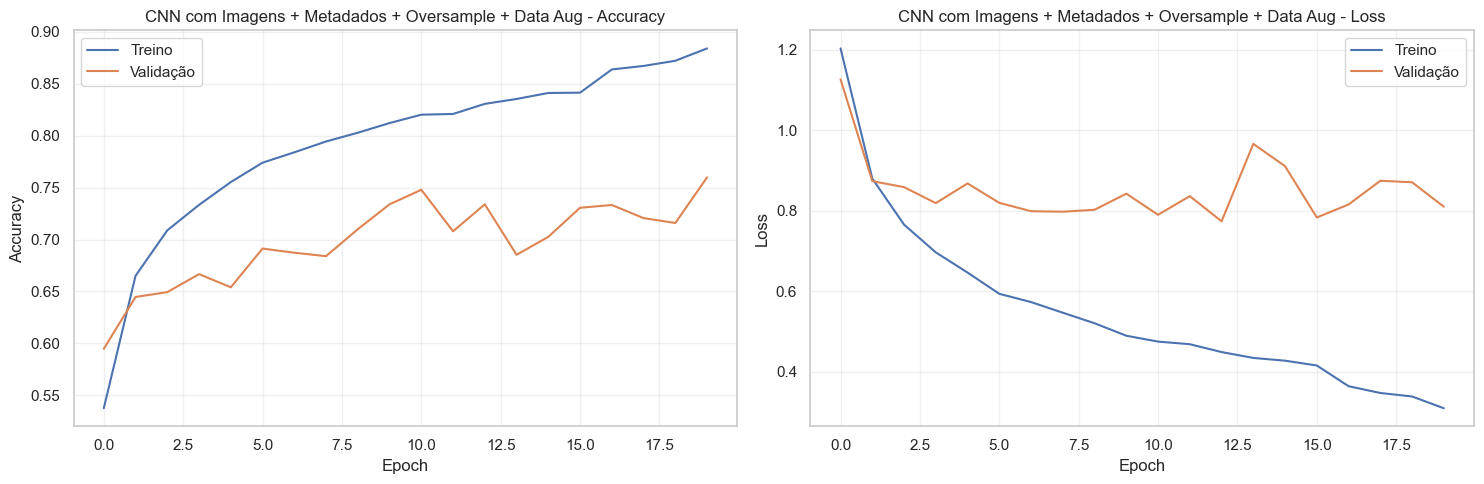

In [141]:
# Linhas de treino/validação
plot_history(history_cnn_meta_over_aug, model_name="CNN com Imagens + Metadados + Oversample + Data Aug")

A combinação de metadados com oversampling e data augmentation muda de forma significativa a dinâmica do treinamento.

Observações principais:

- A acurácia de treino cresce continuamente até cerca de 88%, com trajetória suave e sem oscilações bruscas.

- A acurácia de validação também aumenta de forma consistente, estabilizando em torno de 70–76%, o que indica boa generalização comparado aos modelos anteriores.

- O loss de treino apresenta queda constante, refletindo aprendizado progressivo.

- O loss de validação, apesar de apresentar oscilações típicas de data augmentation, mantém-se estável sem tendência de crescimento, sugerindo controle de overfitting.

In [142]:
# Carregar modelo salvo
model_cnn_meta_over_aug = load_model("models/cnn/all_in.keras")
print("CNN com Imagens + Metadados + Oversample + Data Aug carregada!")

CNN com Imagens + Metadados + Oversample + Data Aug carregada!


CNN com Imagens + Metadados + Oversample + Data Aug:
Acurácia Validação: 73.39%
Acurácia Teste:     70.19%


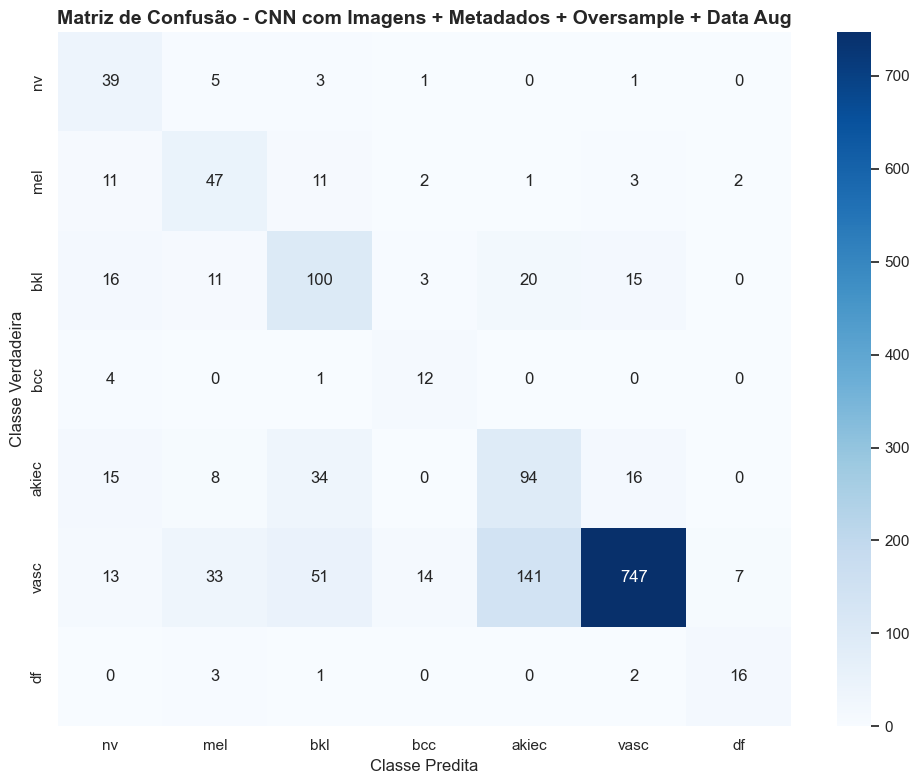

RELATÓRIO DE CLASSIFICAÇÃO - CNN COM IMAGENS + METADADOS + OVERSAMPLE + DATA AUG:
                       precision    recall  f1-score   support

  Nevos melanocíticos     0.3980    0.7959    0.5306        49
             Melanoma     0.4393    0.6104    0.5109        77
    Queratose benigna     0.4975    0.6061    0.5464       165
Carcinoma basocelular     0.3750    0.7059    0.4898        17
   Queratose actínica     0.3672    0.5629    0.4444       167
    Lesões vasculares     0.9528    0.7425    0.8346      1006
       Dermatofibroma     0.6400    0.7273    0.6809        22

             accuracy                         0.7019      1503
            macro avg     0.5242    0.6787    0.5768      1503
         weighted avg     0.7822    0.7019    0.7270      1503



In [143]:
# Predições
y_val_pred_meta_over_aug_probs = model_cnn_meta_over_aug.predict([X_val, meta_val], verbose=0)
y_test_pred_meta_over_aug_probs = model_cnn_meta_over_aug.predict([X_test, meta_test], verbose=0)

y_val_pred_meta_over_aug = np.argmax(y_val_pred_meta_over_aug_probs, axis=1)
y_test_pred_meta_over_aug = np.argmax(y_test_pred_meta_over_aug_probs, axis=1)

# Resumo de acurácia
print_accuracy_summary(
    model_name="CNN com Imagens + Metadados + Oversample + Data Aug",
    y_val_true=y_val,
    y_val_pred=y_val_pred_meta_over_aug,
    y_test_true=y_test,
    y_test_pred=y_test_pred_meta_over_aug,
)

# Matriz de confusão + classification_report
plot_confusion_and_report(
    y_true=y_test,
    y_pred=y_test_pred_meta_over_aug,
    class_names=class_names,
    model_name="CNN com Imagens + Metadados + Oversample + Data Aug",
)

1. Métricas globais

- Acurácia geral: **70,19%**, inferior à CNN com metadados sem desbalanceamento (74,72%), mas com melhor equilíbrio entre as classes.
- Macro avg:

  - recall ≈ 0,68
  - F1 ≈ 0,58
  - Esses valores representam o **melhor recall macro** entre todas as abordagens testadas até agora.
- Weighted avg:

  - recall ≈ 0,70
  - F1 ≈ 0,73
  - Bons resultados globais, embora com leve queda em acurácia geral por conta da penalização da classe majoritária.

Conclusão parcial: o modelo sacrifica um pouco de acurácia bruta, mas **ganha muito em equilíbrio entre classes**, especialmente para aquelas minoritárias.

2. Métricas por classe

| Classe                | support | precision | recall | f1-score | Comentário                                                                              |
| --------------------- | ------- | --------- | ------ | -------- | --------------------------------------------------------------------------------------- |
| Nevos melanocíticos   | 49      | 0.40      | 0.80   | 0.53     | Forte avanço; recupera muitos casos reais.                            |
| Melanoma              | 77      | 0.44      | 0.61   | 0.51     | Desempenho Médio.                                 |
| Queratose benigna     | 165     | 0.50      | 0.61   | 0.55     | Sensível melhora em todas as métricas.                                                  |
| Carcinoma basocelular | 17      | 0.38      | 0.71   | 0.49     | Um dos maiores ganhos: recall muito superior aos modelos sem técnicas de balanceamento. |
| Queratose actínica    | 167     | 0.37      | 0.56   | 0.44     | Bom avanço em recall; resultado equilibrado.                                            |
| Lesões vasculares     | 1006    | 0.95      | 0.74   | 0.83     | Recall menor por perda de dominância, mas excelente precisão e F1 muito alto.           |
| Dermatofibroma        | 22      | 0.64      | 0.73   | 0.68     | Desempenho Bom        |

Essas métricas mostram que o modelo com oversampling + data augmentation + metadados é o mais equilibrado até agora. Quase todas as classes atingem recall superior a 50%, incluindo classes críticas e antes extremamente problemáticas, como carcinoma basocelular e nevos melanocíticos.

3. Conclusão

A CNN com imagens + metadados + oversampling + data augmentation é, até este ponto, o modelo **mais equilibrado no desempenho entre as classes**. Embora a acurácia geral seja menor que o modelo com metadados sem balanceamento, o ganho em recall nas classes minoritárias é substancial, e esse é o ponto central em um problema clínico, onde perder casos críticos é inaceitável.

A combinação das três estratégias mostra-se eficaz:

* **Metadados** fornecem contexto adicional e ajudam a separar classes difíceis.
* **Oversampling** aumenta a representatividade das classes minoritárias.
* **Data augmentation** impede o overfitting gerado pelas duplicações do oversampling.

O resultado é um modelo que detecta muito melhor classes raras, mantém desempenho forte na classe majoritária e apresenta as melhores métricas macro até agora.


---

## Vision Transformer  Manual (ViTs)

### 1. Conceito Transformer

Transformers são arquiteturas baseadas inteiramente em **mecanismos de atenção**, introduzidas no artigo clássico *"Attention is All You Need"* (Vaswani et al., 2017).

A ideia central é permitir que cada token da sequência **interaja diretamente com todos os outros**, capturando dependências longas e o “contexto global” de forma eficiente.


1. **Embeddings**

A sequência de entrada é convertida em vetores (**embeddings**), que representam o “significado básico” de cada token em um espaço vetorial. O contexto ainda não está incorporado aqui, ele será modelado pelo mecanismo de atenção.


$X = {x_1, x_2, \dots, x_n}, \quad x_i \in \mathbb{R}^{d_{\text{model}}}$

2. **Projeções Q, K e V**

A partir desses embeddings, o modelo aprende três projeções lineares para cada token: Query, Key, Value.


$Q = X W_Q, \qquad K = X W_K, \qquad V = X W_V$

onde ($W_Q$, $W_K$, $W_V$) são matrizes de pesos treináveis.


3. **Atenção baseada em similaridade**

O “quanto” cada token deve prestar atenção em outro é medido pela similaridade entre queries e keys:

$\text{scores} = \frac{QK^\top}{\sqrt{d_k}}$


4. **Softmax e combinação de valores**

Esses scores são normalizados com softmax e usados para combinar os valores (V): 

$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$

O resultado é uma **nova representação contextualizada** de cada token, que agora leva em conta toda a sequência.


5. **Multi-Head Self-Attention**

O modelo divide (Q), (K) e (V) em várias “cabeças” para aprender diferentes tipos de relações:

$\text{head}_i = \text{Attention}(Q_i, K_i, V_i)$

$\text{MultiHead}(X) = \text{Concat}(\text{head}_1,\dots,\text{head}_h) W_O$

onde ($W_O$) é outra matriz de projeção treinável.

6. **Feed-Forward Network (MLP por token)**

Em seguida, cada posição passa por uma rede totalmente conectada **independente por token**, adicionando não linearidade ao modelo:

$\text{FFN}(x) = W_2 , \sigma(W_1 x + b_1) + b_2$

7. **Layer Normalization**

A normalização por camada ajuda a estabilizar e acelerar o treinamento:

$\text{Norm}(x) = \frac{x - \mu}{\sigma}$

onde ($\mu$) e ($\sigma$) são a média e o desvio padrão por feature.

8. **Skip Connections (residual)**

Conexões residuais facilitam a propagação de gradientes (evitam vanishing gradient) e permitem treinar modelos profundos:

$Z = \text{LayerNorm}(X + \text{MultiHead}(X))$

$\text{Output} = \text{LayerNorm}(Z + \text{FFN}(Z))$


9. **Aplicações**

Embora tenha surgido em NLP, essa arquitetura rapidamente se expandiu para:

* visão computacional (ViT)
* áudio e fala
* bioinformática
* robótica
* aprendizado por reforço


---

### 2. Vision Transformer

O Vision Transformer (ViT) aplica a ideia de Transformer em imagens:

1. A imagem é dividida em **patches** (por exemplo, 16×16 ou 8×8 pixels)
2. Cada patch é achatado em um vetor e projetado em um espaço de dimensão fixa (embedding)
3. Os patches são tratados como uma "sequência" de tokens, como se cada patch fosse uma palavra
4. Adicionamos **embeddings de posição** para o modelo saber onde cada patch fica na imagem
5. Essa sequência passa por vários blocos Transformer
6. No final, agregamos a informação dos tokens e fazemos a classificação

Vantagens:

- Modelo pode aprender relações de longo alcance entre regiões da imagem
- Escala bem para modelos muito grandes
- Permite reutilizar a mesma arquitetura de NLP

Desvantagens:

- Precisa de muitos dados ou algum tipo de pré-treino

---

### 3. Modelo Utilizado

Neste caso foi implementado um **Vision Transformer Mini (ViT-Mini)** do zero usando apenas `tf.keras`, com foco em ser leve e treinável no nosso dataset de câncer de pele.

Principais características do modelo:

- Entrada: imagens RGB `128×128×3` já padronizadas (z-score)
- `patch_size = 8` → 16×16 patches = 256 tokens
- `projection_dim = 64` 
- `num_heads = 4` cabeças de atenção
- `transformer_layers = 6` blocos Transformer empilhados
- `mlp_dim = 128` na parte feed-forward interna
- Pooling global sobre os tokens para produzir um vetor fixo
- Cabeça densa para classificação nas 7 classes do conjunto HAM10000.

O treinamento é feito:

- Com **Oversampling** e **data augmentation** (flip, rotação, zoom) embutido no modelo;

---

### 4. Construção Modelo

#### Camada de Patches

In [51]:
class Patches(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        # Tamanho do batch em runtime
        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )

        # Dimensão de cada patch "achatado"
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config

#### Patch + Position Embedding

In [52]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim

        # Projeção linear de cada patch para o espaço de embedding
        self.projection = layers.Dense(projection_dim)

        # Embedding de posição [0 .. num_patches-1]
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patches):
        # Vetor [0, 1, 2, ..., num_patches-1]
        positions = tf.range(start=0, limit=self.num_patches, delta=1)

        # Projeção dos patches + embedding de posição 
        encoded = self.projection(patches) + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim,
        })
        return config


##### Data Augmentation

In [53]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)

#### ViT-Mini

In [54]:
input_shape = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)
def create_vit_mini_model(
    input_shape,
    num_classes,
    patch_size=8,
    projection_dim=64,
    num_heads=4,
    transformer_layers=6,
    mlp_dim=128,
):
    # Entrada do modelo: imagem 128×128×3 (já padronizada)
    inputs = keras.Input(shape=input_shape, name="image_input")

    # Aplica data augmentation apenas em modo de treino
    x = data_augmentation(inputs)

    # 1) Camada de patches: imagem → sequência de patches
    patches = Patches(patch_size, name="patches")(x)

    # 2) Embedding de patches + posição
    num_patches = (input_shape[0] // patch_size) * (input_shape[1] // patch_size)
    encoded_patches = PatchEncoder(
        num_patches=num_patches,
        projection_dim=projection_dim,
        name="patch_encoder",
    )(patches)

    # 3) Blocos Transformer empilhados
    encoded = encoded_patches
    for i in range(transformer_layers):
        # Normalização antes da atenção
        x1 = layers.LayerNormalization(epsilon=1e-6, name=f"ln_attn_{i}")(encoded)

        # Multi-head self-attention: cada token "olha" para todos os outros
        attn_output = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=projection_dim // num_heads,
            dropout=0.0,
            name=f"mha_{i}",
        )(x1, x1)

        # Skip connection (residual) atenção
        x2 = layers.Add(name=f"skip_attn_{i}")([attn_output, encoded])

        # MLP interno por token (feed-forward)
        x3 = layers.LayerNormalization(epsilon=1e-6, name=f"ln_mlp_{i}")(x2)
        x3 = layers.Dense(mlp_dim, activation=tf.nn.gelu, name=f"mlp_{i}_dense_1")(x3)
        x3 = layers.Dense(projection_dim, name=f"mlp_{i}_dense_2")(x3)

        # Skip connection (residual) MLP
        encoded = layers.Add(name=f"skip_mlp_{i}")([x3, x2])

    # 4) Pooling global sobre os tokens (média das representações dos patches)
    representation = layers.LayerNormalization(epsilon=1e-6, name="ln_final")(encoded)
    representation = layers.GlobalAveragePooling1D(name="gap_tokens")(representation)

    # 5) Cabeça de classificação final
    x = layers.Dropout(0.3, name="head_dropout_1")(representation)
    x = layers.Dense(128, activation="relu", name="head_dense_1")(x)
    x = layers.Dropout(0.3, name="head_dropout_2")(x)
    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="predictions",
    )(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="vit_mini_skin_cancer")
    return model


In [55]:
# Construção do modelo
num_classes = y_train_encoded.shape[1]  # ou defina explicitamente
model_vit_mini = create_vit_mini_model(input_shape, num_classes)
model_vit_mini.summary()

Model: "vit_mini_skin_cancer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 128, 128,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 192) │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 256, 64)   │     28,736 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_attn_0           │ (None, 256, 64)   │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha_0               │ (None, 256, 64)   │     16,640 │ ln_attn_0[0][0],  │
│ (MultiHeadAttentio… │                   │            │ ln_attn_0[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_attn_0 (Add)   │ (None, 256, 64)   │          0 │ mha_0[0][0],      │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_mlp_0            │ (None, 256, 64)   │        128 │ skip_attn_0[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_0_dense_1       │ (None, 256, 128)  │      8,320 │ ln_mlp_0[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_0_dense_2       │ (None, 256, 64)   │      8,256 │ mlp_0_dense_1[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_mlp_0 (Add)    │ (None, 256, 64)   │          0 │ mlp_0_dense_2[0]… │
│                     │                   │            │ skip_attn_0[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_attn_1           │ (None, 256, 64)   │        128 │ skip_mlp_0[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha_1               │ (None, 256, 64)   │     16,640 │ ln_attn_1[0][0],  │
│ (MultiHeadAttentio… │                   │            │ ln_attn_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_attn_1 (Add)   │ (None, 256, 64)   │          0 │ mha_1[0][0],      │
│                     │                   │            │ skip_mlp_0[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_mlp_1            │ (None, 256, 64)   │        128 │ skip_attn_1[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_1_dense_1       │ (None, 256, 128)  │      8,320 │ ln_mlp_1[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_1_dense_2       │ (None, 256, 64)   │      8,256 │ mlp_1_dense_1[0]… │
│ (Dense)             │                   │            │                 

 Total params: 238,919 (933.28 KB)

 Trainable params: 238,919 (933.28 KB)

 Non-trainable params: 0 (0.00 B)

#### Compilação

In [56]:
learning_rate = 3e-4

model_vit_mini.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print("Modelo ViT-Mini compilado.")


Modelo ViT-Mini compilado.


### Treino

In [57]:
EPOCHS_VIT = EPOCHS 
# Oversampling no treino
X_train_vit_over, y_train_vit_over = oversample_by_class(X_train, y_train, random_state=SEED)
y_train_vit_over_encoded = to_categorical(y_train_vit_over, num_classes=num_classes)


lr_reduction_vit = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    factor=0.5,
    min_lr=1e-6,
    verbose=1,
)

early_stop_vit = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1,
)


history_vit_mini = model_vit_mini.fit(
    X_train_vit_over,
    y_train_vit_over_encoded,
    validation_data=(X_val, y_val_encoded),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[lr_reduction_vit, early_stop_vit],
)


Epoch 1/30
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 157s 143ms/step - accuracy: 0.4618 - loss: 1.3724 - val_accuracy: 0.5549 - val_loss: 1.0283 - learning_rate: 3.0000e-04
Epoch 2/30
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 154s 150ms/step - accuracy: 0.6474 - loss: 0.9328 - val_accuracy: 0.6048 - val_loss: 0.9196 - learning_rate: 3.0000e-04
Epoch 3/30
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 153s 149ms/step - accuracy: 0.7263 - loss: 0.7373 - val_accuracy: 0.6494 - val_loss: 0.8485 - learning_rate: 3.0000e-04
Epoch 4/30
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 148s 144ms/step - accuracy: 0.7784 - loss: 0.6082 - val_accuracy: 0.6267 - val_loss: 0.9105 - learning_rate: 3.0000e-04
Epoch 5/30
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 152s 148ms/step - accuracy: 0.8110 - loss: 0.5131 - val_accuracy: 0.6766 - val_loss: 0.8365 - learning_rate: 3.0000e-04
Epoch 6/30
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 146s 142ms/step - accuracy: 0.8401 - loss: 0.4409 - val_accuracy: 0.6514 - val_loss: 0.9227 - learning_rate: 3.0000e-04
Epoch 7/30
1027/1027 ━━━━━━━

In [65]:
# Salvar modelo
model_vit_mini.save("models/viti/mini.h5")
print("ViT-Mini salva em models/viti/mini.keras")

ViT-Mini salva em models/viti/mini.keras


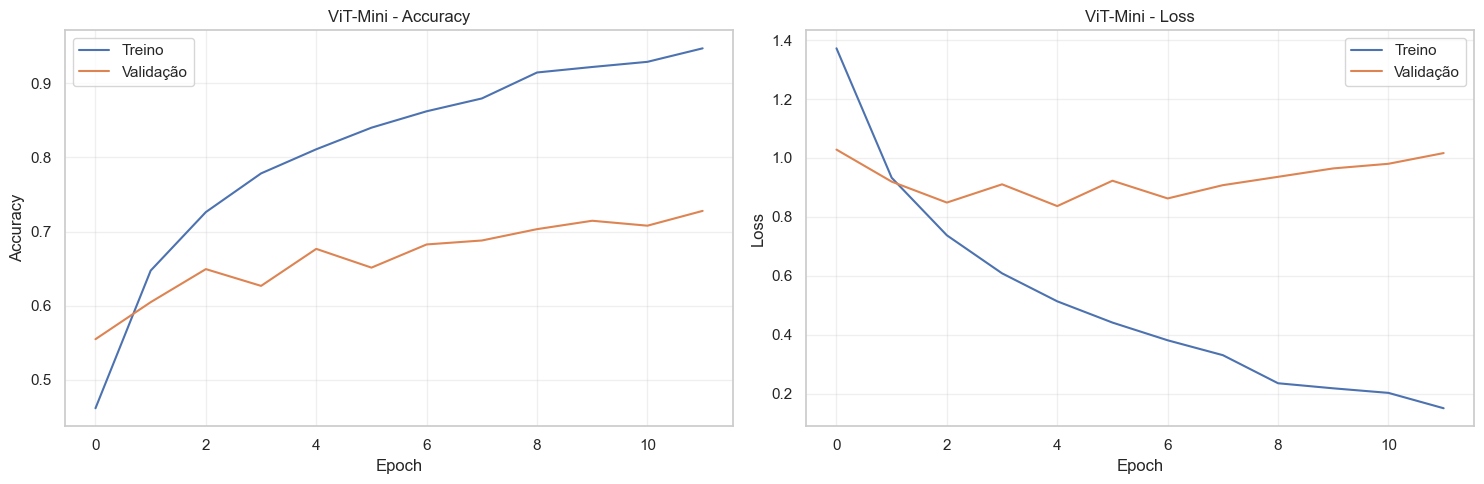

In [59]:
# Curvas de treino/validação
plot_history(history_vit_mini, model_name="ViT-Mini")

O ViT-Mini apresenta um comportamento distinto das CNNs. Mesmo treinado do zero, ele converge rapidamente e mantém estabilidade razoável no conjunto de validação.

Principais observações:

- A acurácia de treino cresce continuamente, chegando a aproximadamente 94%.

- A acurácia de validação estabiliza entre 68% e 72%, sem quedas bruscas, mas também sem acompanhar integralmente o treino.

- O loss de treino cai de forma consistente até valores muito baixos (≈0.15).

- O loss de validação, no entanto, não acompanha a redução do treino e permanece estável na faixa 0.85–1.0, oscilando ao longo das épocas.

In [66]:
# Carregar modelo salvo
model_vit_mini = load_model("models/viti/mini.h5", custom_objects={"Patches": Patches, "PatchEncoder": PatchEncoder})
print("ViT-Mini carregada!")

ViT-Mini carregada!


Vision Transformer Mini (from scratch):
Acurácia Validação: 67.66%
Acurácia Teste:     67.13%


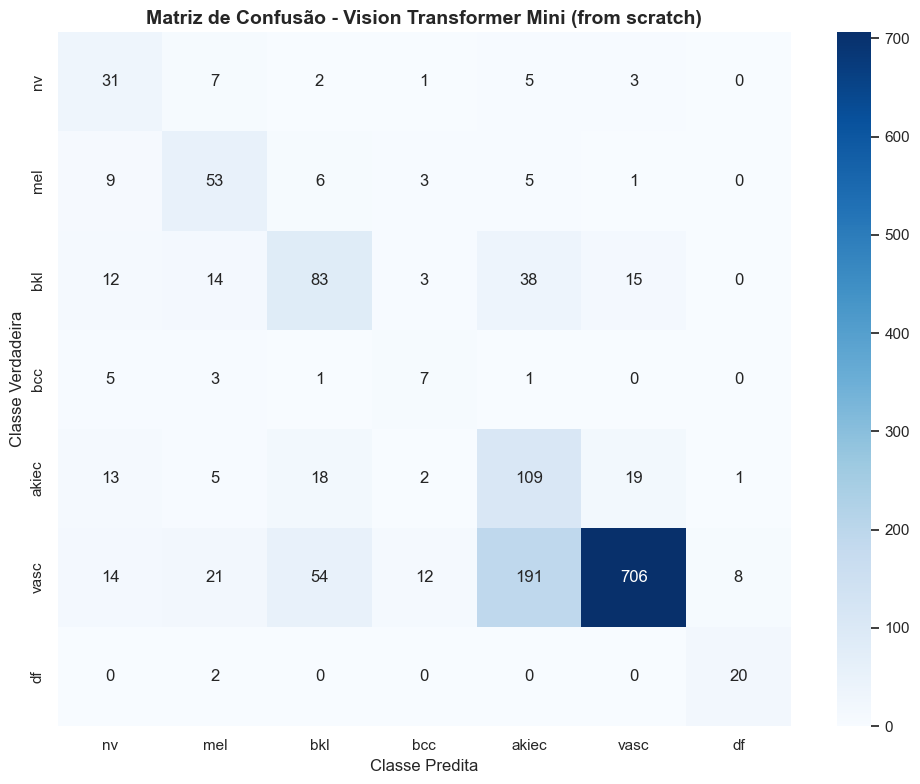

RELATÓRIO DE CLASSIFICAÇÃO - VISION TRANSFORMER MINI (FROM SCRATCH):
                       precision    recall  f1-score   support

  Nevos melanocíticos     0.3690    0.6327    0.4662        49
             Melanoma     0.5048    0.6883    0.5824        77
    Queratose benigna     0.5061    0.5030    0.5046       165
Carcinoma basocelular     0.2500    0.4118    0.3111        17
   Queratose actínica     0.3123    0.6527    0.4225       167
    Lesões vasculares     0.9489    0.7018    0.8069      1006
       Dermatofibroma     0.6897    0.9091    0.7843        22

             accuracy                         0.6713      1503
            macro avg     0.5115    0.6428    0.5540      1503
         weighted avg     0.7762    0.6713    0.7024      1503



In [68]:
# Probabilidades
y_val_pred_proba_vit  = model_vit_mini.predict(X_val,  verbose=0)
y_test_pred_proba_vit = model_vit_mini.predict(X_test, verbose=0)

# Classe predita (argmax)
y_val_pred_vit  = np.argmax(y_val_pred_proba_vit,  axis=1)
y_test_pred_vit = np.argmax(y_test_pred_proba_vit, axis=1)

# Resumo de acurácia
print_accuracy_summary(
    model_name="Vision Transformer Mini (from scratch)",
    y_val_true=y_val,
    y_val_pred=y_val_pred_vit,
    y_test_true=y_test,
    y_test_pred=y_test_pred_vit,
)

# Matriz de confusão + classification_report no teste
plot_confusion_and_report(
    y_true=y_test,
    y_pred=y_test_pred_vit,
    class_names=class_names,
    model_name="Vision Transformer Mini (from scratch)",
)


1. Métricas globais

- Acurácia geral: **67,13%**, superior ao oversampling simples (61,28%) e pesos de classe (62,21%), mas inferior ao modelo metadados puro (74,72%) e ao metadados + oversample + augmentation (70,19%).
- Macro avg:

  - recall ≈ 0,64
  - F1 ≈ 0,55
  - O ViT-Mini apresenta um dos **melhores recalls macro** entre os modelos.
- Weighted avg:

  - recall ≈ 0,67
  - F1 ≈ 0,70
  - Valores sólidos, demonstrando bom equilíbrio geral.

Conclusão parcial: apesar da acurácia global moderada, o ViT apresenta ** capacidade de detectar classes minoritárias**, beneficiando-se do mecanismo de atenção.

2. Métricas por classe

| Classe                | support | precision | recall | f1-score | Comentário                                                                                              |
| --------------------- | ------- | --------- | ------ | -------- | ------------------------------------------------------------------------------------------------------- |
| Nevos melanocíticos   | 49      | 0.37      | 0.63   | 0.47     | Detecta mais da metade dos casos.                                             |
| Melanoma              | 77      | 0.50      | 0.69   | 0.58     | Bom Recall                                |
| Queratose benigna     | 165     | 0.51      | 0.50   | 0.50     | Desempenho médio                                                              |
| Carcinoma basocelular | 17      | 0.25      | 0.41   | 0.31     | Desempenho Médio/Baixo |
| Queratose actínica    | 167     | 0.31      | 0.65   | 0.42     | Um dos maiores recalls para esta classe; ViT capta bem suas variações.                                  |
| Lesões vasculares     | 1006    | 0.95      | 0.70   | 0.81     | A precisão permanece alta, mas o recall cai devido ao foco maior em classes minoritárias.               |
| Dermatofibroma        | 22      | 0.69      | 0.91   | 0.78     | Bom desempenho; melhor recall para essa classe até agora.                                         |


3. Conclusão

O ViT-Mini demonstra forte capacidade de generalização interclasse e sensibilidade para padrões difíceis, mas carece de regularização extra ou mais dados para alcançar o mesmo nível de acurácia global que a combinação CNN + metadados. Ainda assim, ele representa um avanço promissor e competitivo entre os modelos avaliados.


---

## Resultados e Comparação entre Modelos

Nesta seção comparamos o desempenho dos diferentes modelos treinados:

- **Dummy**: classificador base que sempre prediz a classe majoritária (*Lesões vasculares*);
- **CNNs**: arquiteturas convolucionais treinadas ao longo do notebook (modelos 2D padrão de visão);
- **ViT-Mini**: Vision Transformer Mini implementado manualmente, treinado do zero com oversampling e data augmentation.

O objetivo é ver qual modelo obteve o melhor resultado de detecção de diagnósticos.

---

### 1. Carregamento de Modelos

In [145]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import label_binarize

# --------------------------------------------------
# 0.1) Mapear classes em uma lista na ordem dos índices
#     (assumindo que você criou os índices na mesma ordem do dict)
# --------------------------------------------------
idx_to_class = list(class_names.values())   # ['Nevos ...', 'Melanoma', ...]
num_classes = len(idx_to_class)

# --------------------------------------------------
# 0.2) Carregar modelos salvos
# --------------------------------------------------
keras_models = {
    "CNN Simples": load_model("models/cnn/simple.keras"),
    "CNN com Pesos de Classe": load_model("models/cnn/class_weights.keras"),
    "CNN com Oversampling": load_model("models/cnn/oversampling.keras"),
    "CNN com Oversampling + Data Aug": load_model("models/cnn/augmentada.keras"),
    "CNN Imagens + Metadados": load_model("models/cnn/metadata.keras"),
    "CNN All-in (Img+Meta+Over+Aug)": load_model("models/cnn/all_in.keras"),
    "ViT-Mini": load_model(
        "models/viti/mini.h5",
        custom_objects={"Patches": Patches, "PatchEncoder": PatchEncoder}
    ),
}

# Dummy exatamente como no notebook
dummy_model = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy_model.fit(X_train, y_train)

all_models = {"Dummy Classifier": dummy_model}
all_models.update(keras_models)
# --------------------------------------------------
# 0.3) Gerar predições, probabilidades e métricas
# --------------------------------------------------

def predict_model(model, X_test, meta_test):
    """Retorna y_proba, y_pred considerando se o modelo tem 1 ou 2 inputs."""
    # Detecta quantos inputs o modelo tem
    n_inputs = len(model.inputs)

    if n_inputs == 1:
        # Modelos que usam somente imagem
        y_proba = model.predict(X_test, verbose=0)

    elif n_inputs == 2:
        # Modelos que usam imagem + metadados
        y_proba = model.predict([X_test, meta_test], verbose=0)

    else:
        raise ValueError(f"Modelo possui {n_inputs} inputs, não tratado automaticamente.")

    # Caso seja um modelo Keras, retornará probabilidades (N, C)
    y_pred = np.argmax(y_proba, axis=1)
    return y_proba, y_pred


results = {}

for name, model in all_models.items():

    if isinstance(model, DummyClassifier):
        # Dummy usa apenas imagem mesmo
        y_proba = model.predict_proba(X_test)
        y_pred  = model.predict(X_test)

    else:
        # Detecta automaticamente 1 ou 2 entradas
        y_proba, y_pred = predict_model(model, X_test, meta_test)

    # Métricas
    report_dict = classification_report(
        y_test,
        y_pred,
        target_names=idx_to_class,
        digits=4,
        zero_division=0,
        output_dict=True
    )

    results[name] = {
        "y_pred": y_pred,
        "y_proba": y_proba,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "weighted_f1": f1_score(y_test, y_pred, average="weighted"),
        "report": report_dict,
    }


---

### 2. Acurácia, F1 macro, F1 weighted

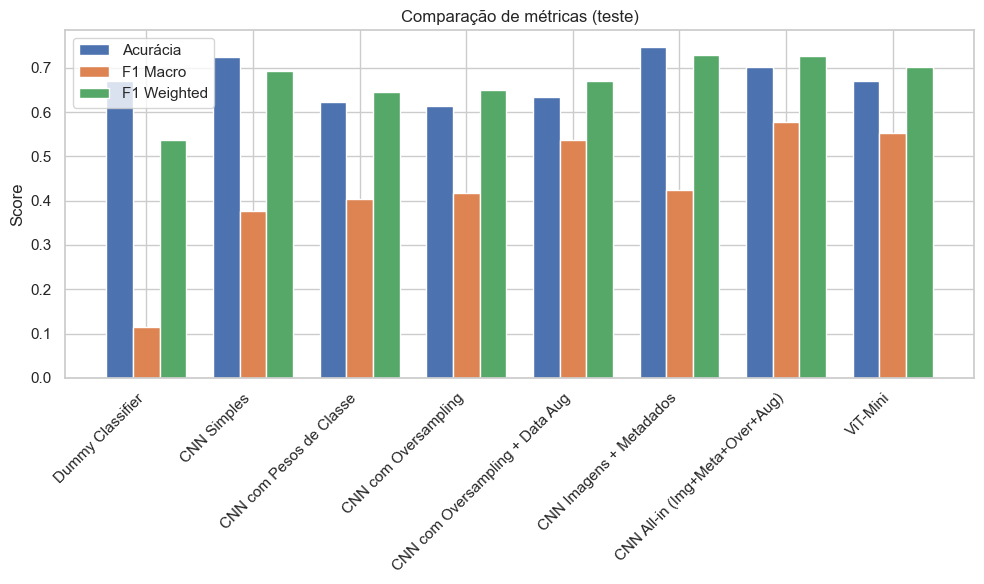

In [146]:
model_order = list(results.keys())  # se quiser, muda a ordem manualmente

accuracies   = [results[m]["accuracy"]   for m in model_order]
macro_f1s    = [results[m]["macro_f1"]   for m in model_order]
weighted_f1s = [results[m]["weighted_f1"] for m in model_order]

x = np.arange(len(model_order))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, accuracies,   width, label="Acurácia")
plt.bar(x,         macro_f1s,    width, label="F1 Macro")
plt.bar(x + width, weighted_f1s, width, label="F1 Weighted")

plt.xticks(x, model_order, rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Comparação de métricas (teste)")
plt.legend()
plt.tight_layout()
plt.show()


O gráfico acima ilustra o perigo de confiar apenas na **Acurácia** em datasets desbalanceados. Note que:

1.  **O Ilusionismo do Baseline:** O `Dummy Classifier` (apenas chutando a classe majoritária) atinge uma acurácia alta (~67%), superior a modelos complexos como a `CNN com Oversampling`. Se olhássemos apenas para a barra azul, o modelo Dummy pareceria competitivo.
2.  **A Verdade no F1-Macro:** A barra laranja (F1-Macro) revela a realidade. O Dummy tem desempenho próximo de zero, pois ignora as classes raras. Já o modelo `CNN All-in (Img+Meta+Over+Aug)` atinge o maior F1-Macro, indicando que é o modelo que melhor equilibra o desempenho entre **todas** as classes, não apenas na majoritária.
3.  **Impacto do Oversampling:** Comparando a `CNN Simples` com a `CNN com Oversampling`. Nota-se que a acurácia (azul) cai no segundo caso, mas o F1-Macro (laranja) sobe. Isso confirma que o modelo sacrificou um pouco da performance na classe dominante para aprender a detectar as doenças raras (Melanoma, Carcinoma), o que é clinicamente mais valioso.

### 3. F1-score por classe

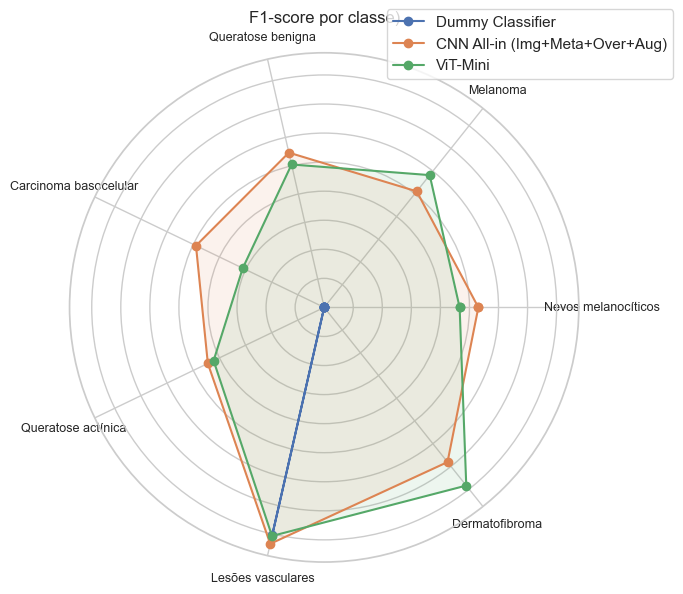

In [148]:
# escolha quais modelos quer no radar
selected_models = [
    "Dummy Classifier",
    "CNN All-in (Img+Meta+Over+Aug)",
    "ViT-Mini",
]

labels = idx_to_class
n_classes = len(labels)

# ângulos do radar
angles = np.linspace(0, 2 * np.pi, n_classes, endpoint=False)
angles = np.concatenate([angles, [angles[0]]])  # fecha o círculo

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

for model_name in selected_models:
    report = results[model_name]["report"]
    f1_per_class = [report[label]["f1-score"] for label in labels]
    f1_per_class = np.concatenate([f1_per_class, [f1_per_class[0]]])

    ax.plot(angles, f1_per_class, marker="o", label=model_name)
    ax.fill(angles, f1_per_class, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)
ax.set_yticklabels([])
ax.set_title("F1-score por classe)")
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.show()


O gráfico de radar permite visualizar a "forma" do aprendizado de cada modelo:

-   **Dummy Classifier (Azul):** É apenas um ponto concentrado no centro e esticado em direção a `Lesões vasculares`. Ele é cego para todo o resto.
-   **ViT-Mini (Verde):** Apresenta uma forma muito mais distribuída, com destaque surpreendente para `Dermatofibroma` e `Melanoma`. Isso mostra que, mesmo sendo uma arquitetura "Mini" treinada do zero, o mecanismo de atenção conseguiu capturar características distintivas dessas lesões.
-   **CNN All-in (Laranja):** É o polígono mais "aberto" e regular. Ele cobre melhor as áreas de `Carcinoma basocelular` e `Nevos melanocíticos` do que os outros. Essa cobertura mais ampla confirma que a combinação de **Metadados + Oversampling + Data Augmentation** foi a estratégia mais eficaz para generalização entre classes.

### 4. Onde os modelos mais erram

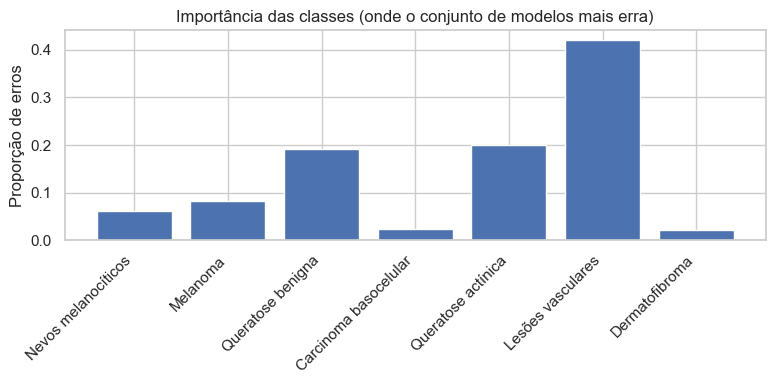

In [149]:
error_counts = {label: 0.0 for label in idx_to_class}

for model_name, info in results.items():
    rep = info["report"]
    for label in idx_to_class:
        support = rep[label]["support"]
        recall  = rep[label]["recall"]
        errors  = support * (1.0 - recall)
        error_counts[label] += errors

# transforma em vetor e normaliza (opcional)
labels = list(error_counts.keys())
errors = np.array([error_counts[l] for l in labels], dtype=float)
errors_norm = errors / errors.sum()

plt.figure(figsize=(8, 4))
plt.bar(labels, errors_norm)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Proporção de erros")
plt.title("Importância das classes (onde o conjunto de modelos mais erra)")
plt.tight_layout()
plt.show()


Este gráfico mostra a distribuição absoluta dos erros cometidos pelo conjunto de modelos.

-   **Volume vs. Taxa:** A barra de `Lesões vasculares` é a mais alta não porque o modelo é ruim nela (pelo contrário, é a classe com maior acurácia), mas simplesmente porque ela representa a vasta maioria do dataset. 5% de erro em 5000 imagens gera mais volume do que 50% de erro em 100 imagens.
-   **As Confusões Reais:** As barras de `Queratose benigna` e `Melanoma` são significativas. Clinicamente, a confusão visual entre *Melanoma* (maligno) e *Nevos* ou *Queratose* (benignos) é o maior desafio, tanto para dermatologistas quanto para os modelos, devido à similaridade visual das bordas e pigmentação.

### 5. Curva PR micro-average

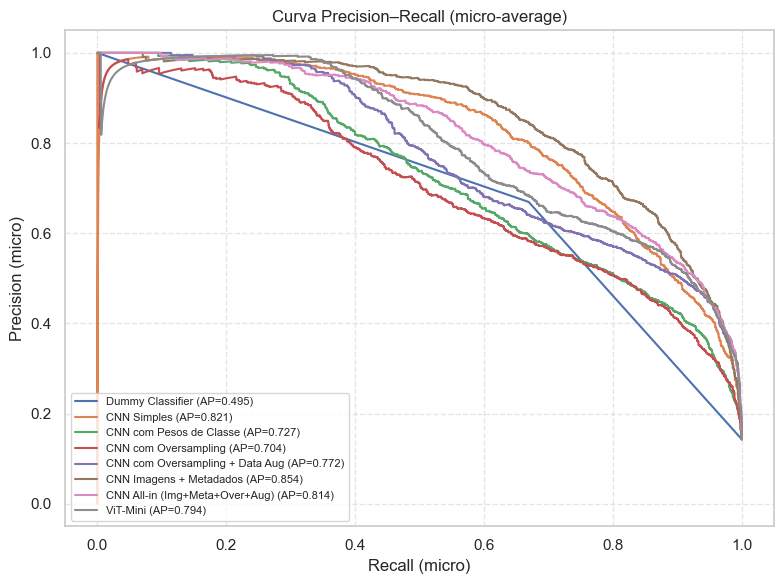

In [150]:
from sklearn.metrics import precision_recall_curve, average_precision_score

y_true_bin = label_binarize(y_test, classes=np.arange(num_classes))

plt.figure(figsize=(8, 6))

for model_name in model_order:
    y_score = results[model_name]["y_proba"]  # (N, C)

    precision, recall, _ = precision_recall_curve(
        y_true_bin.ravel(), y_score.ravel()
    )
    ap_micro = average_precision_score(
        y_true_bin, y_score, average="micro"
    )

    plt.plot(recall, precision, label=f"{model_name} (AP={ap_micro:.3f})")

plt.xlabel("Recall (micro)")
plt.ylabel("Precision (micro)")
plt.title("Curva Precision–Recall (micro-average)")
plt.legend(loc="lower left", fontsize=8)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


A curva Precision-Recall (micro) resume a capacidade de ordenação dos modelos.

-   O modelo **CNN Imagens + Metadados (Linha Marrom)** obteve o maior AP (0.854). Isso indica que ele é muito confiável quando diz que "é X", mantendo alta precisão.
-   Entretanto, em triagem médica, muitas vezes preferimos um modelo com maior *Recall* (Sensibilidade) nas classes raras, mesmo que a precisão global (micro) caia um pouco.
-   O **ViT-Mini (Linha Cinza)**, com AP de 0.794, mostra-se competitivo, ficando muito próximo das arquiteturas baseadas em CNN (como a All-in com 0.814), provando a viabilidade de Transformers para este problema.

### 6. t-SNE das embeddings do ViT

In [151]:
from tensorflow.keras.models import Model

vit_model = keras_models["ViT-Mini"]

# usa a penúltima camada como embedding (camada antes do softmax final)
vit_embedding_model = Model(
    inputs=vit_model.input,
    outputs=vit_model.layers[-2].output
)

vit_embeddings = vit_embedding_model.predict(X_test, batch_size=64, verbose=0)
vit_embeddings.shape  # (N, D)


(1503, 128)

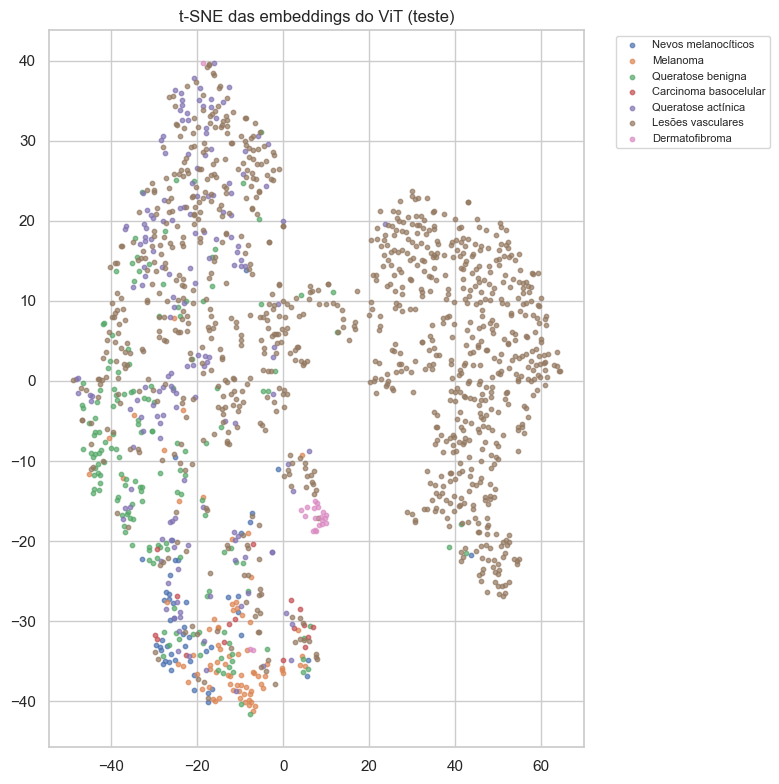

In [154]:
from sklearn.manifold import TSNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,       # <--- CORREÇÃO
    random_state=SEED,
)

emb_tsne = tsne.fit_transform(vit_embeddings)


plt.figure(figsize=(8, 8))
for idx, label in enumerate(idx_to_class):
    mask = (y_test == idx)
    plt.scatter(
        emb_tsne[mask, 0],
        emb_tsne[mask, 1],
        s=10,
        alpha=0.7,
        label=label,
    )

plt.title("t-SNE das embeddings do ViT (teste)")
plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


A projeção t-SNE das embeddings geradas pelo Vision Transformer mostra como a rede "organiza" o conhecimento no espaço latente antes da classificação final:

1.  **Cluster Definido (Marrom - Lesões Vasculares):** Vemos um agrupamento denso e bem separado à direita. Isso explica por que todos os modelos têm facilidade extrema com essa classe: visualmente, ela é muito distinta das demais.
2.  **Zonas de Confusão (Centro/Esquerda):** As classes como `Nevos melanocíticos` (azul), `Melanoma` (laranja) e `Queratose benigna` (verde) aparecem misturadas em várias regiões. Essa sobreposição visual no espaço de características reflete a dificuldade clínica de distinguir essas lesões apenas por imagem, justificando a necessidade de Metadados para ajudar na separação.

# Conclusão Final

Este projeto analisou diferentes formas de classificar lesões de pele usando o dataset HAM10000. Comparamos desde modelos simples até arquiteturas modernas como Vision Transformers, além de testar se dados clínicos (idade, sexo, local) ajudam no diagnóstico.

### Principais Aprendizados

1.  **Cuidado com a Acurácia:**
    Descobrimos que olhar apenas para a acurácia geral é perigoso. O modelo Dummy teve quase 67% de acurácia só chutando a classe majoritária, mas não servia para nada na prática. Os modelos que realmente aprenderam a diferenciar as doenças tiveram acurácias parecidas, mas foram muito melhores em acertar as classes difíceis.

2.  **Dados Clínicos Ajudam Muito:**
    O modelo que usou as imagens junto com os metadados (idade, sexo, região do corpo) teve os resultados mais equilibrados. Isso mostra que, assim como um médico, a IA toma decisões melhores quando tem o contexto do paciente, não apenas a foto.

### O Vision Transformer (ViT)

O **ViT-Mini** foi um destaque interessante. Mesmo sendo uma tecnologia mais nova e complexa que as CNNs, ele conseguiu resultados competitivos.
*   **Por que ele não foi o campeão absoluto?** Diferente das CNNs, que são naturalmente boas em achar padrões em imagens, os Transformers precisam de **muito mais dados** para aprender do zero. Como nosso dataset é pequeno (apenas 10 mil imagens), ele teve uma desvantagem.
*   **Como melhorar?** Para o ViT superar as CNNs neste projeto, o ideal não seria treinar do zero, mas sim usar **Transfer Learning** (pegar um modelo gigante já treinado pelo Google/Facebook e adaptar para o nosso problema).

### Recomendação Final

Embora nenhum dos modelos construídos terem alcançado valores de acurácia/scores altos suficentes para uma aplicação médica no mundo real, se tivéssemos que escolher um único modelo para usar em um hospital hoje, a recomendação seria o **CNN All-in (Imagens + Metadados + Oversampling)**.

**Motivo:** Na medicina, o erro mais grave é dizer que um paciente está saudável quando ele tem câncer. Este modelo foi o que mostrou o melhor equilíbrio, garantindo que casos graves (como Melanoma) não passem despercebidos, mesmo que isso custe um pouco da precisão geral.